# Modélisation de la sinistralité CAAT Transport

Actuarial analysis notebook for CAAT Transport branches FN/FM/FV, covering data available in `clean.xlsx`, `reglements.xlsx`, and `SAP.xlsx`. All generated tables and charts are saved under `outputs/`.

In [1]:
%matplotlib inline
# CELL 0 — Imports & Setup
import os, warnings
os.environ.setdefault('MPLCONFIGDIR', '/private/tmp/matplotlib')
os.makedirs(os.environ['MPLCONFIGDIR'], exist_ok=True)

import pandas as pd, numpy as np, matplotlib
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import poisson, nbinom, lognorm, gamma as gamma_dist, pareto, kstest
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from pathlib import Path
warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)

OUTPUT_DIR = Path('outputs')
DZD = 'DZD'
STUDY_START = 2014
# Extended to include data through 2024.
STUDY_END = None  # Will be determined from data, then capped at 2024
STUDY_END_CAP = 2024  # All data up to 2024 included


def excel_serial_to_date(series):
    s = pd.Series(series)
    if pd.api.types.is_datetime64_any_dtype(s):
        return pd.to_datetime(s, errors='coerce')
    numeric = pd.to_numeric(s, errors='coerce')
    serial_dates = pd.to_datetime(numeric, origin='1899-12-30', unit='D', errors='coerce')
    parsed_dates = pd.to_datetime(s, errors='coerce')
    return serial_dates.fillna(parsed_dates)


def strip_strings(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype(str).str.strip().replace({'nan': np.nan, 'None': np.nan})
    return df


def read_excel_flexible(path, requested_sheet):
    xls = pd.ExcelFile(path)
    requested_clean = requested_sheet.strip().lower()
    sheet = next((s for s in xls.sheet_names if s.strip().lower() == requested_clean), requested_sheet)
    return strip_strings(pd.read_excel(path, sheet_name=sheet))


def fmt_money(x):
    if pd.isna(x):
        return 'NA'
    return f'{x:,.0f} DZD'


def savefig(path, dpi=120):
    plt.savefig(path, dpi=dpi, bbox_inches='tight')
    plt.show()
    plt.close()


def safe_aic(loglik, k):
    return np.inf if not np.isfinite(loglik) else 2 * k - 2 * loglik

analysis_objects = {}


## 1. Chargement et nettoyage des données

In [2]:
# CELL 1 — Load all sheets
contrats = read_excel_flexible('clean.xlsx', 'claen')
reglements = read_excel_flexible('reglements.xlsx', 'claen')
sap = read_excel_flexible('SAP.xlsx', 'BASE')

print('Contrats:', contrats.shape)
print('Reglements:', reglements.shape)
print('SAP:', sap.shape)

# Determine STUDY_END from actual data if not set
if STUDY_END is None:
    max_years = []
    if 'EXERCICE' in contrats.columns:
        max_years.extend(pd.to_numeric(contrats['EXERCICE'], errors='coerce').dropna().values)
    if 'ANNEE' in reglements.columns:
        max_years.extend(pd.to_numeric(reglements['ANNEE'], errors='coerce').dropna().values)
    if 'EXERCICE' in sap.columns:
        max_years.extend(pd.to_numeric(sap['EXERCICE'], errors='coerce').dropna().values)
    STUDY_END = min(int(max(max_years)), STUDY_END_CAP) if max_years else STUDY_END_CAP
    print(f'Study period set to: {STUDY_START}–{STUDY_END} (cap={STUDY_END_CAP})')

# Sort all dataframes by date to ensure chronological order
# This is important for time-series analysis and GLM modeling
for df, date_cols in [
    (contrats, ["Date d'émission_date", "Date d'éffet_date", "Date d'échéanche_date"]),
    (reglements, ["Mois_date"]),
    (sap, ["Date_de_Declaration_date"]),
]:
    for col in date_cols:
        if col in df.columns:
            try:
                df[col] = pd.to_datetime(df[col], errors='coerce')
            except:
                pass

# Sort by available date columns
if "Date d'émission_date" in contrats.columns:
    contrats = contrats.sort_values("Date d'émission_date", na_position='last').reset_index(drop=True)
if "Mois_date" in reglements.columns:
    reglements = reglements.sort_values("Mois_date", na_position='last').reset_index(drop=True)
if "Date_de_Declaration_date" in sap.columns:
    sap = sap.sort_values("Date_de_Declaration_date", na_position='last').reset_index(drop=True)

print(f'Data sorted by date. Study includes data through {STUDY_END}.')


Contrats: (20349, 13)
Reglements: (4212, 9)
SAP: (5288, 9)
Study period set to: 2014–2024 (cap=2024)
Data sorted by date. Study includes data through 2024.


In [3]:
# CELL 2 — Date conversions and column cleanup
for df in [contrats, reglements, sap]:
    df.columns = [str(c).strip() for c in df.columns]

# Contrats dates
for col in ["Date d'émission", "Date d'éffet", "Date d'échéanche"]:
    if col in contrats.columns:
        contrats[col + '_date'] = excel_serial_to_date(contrats[col])

# Reglements dates
if 'Mois' in reglements.columns:
    reglements['Mois_date'] = excel_serial_to_date(reglements['Mois'])
    reglements['Mois_year'] = reglements['Mois_date'].dt.year
    reglements['Mois_month'] = reglements['Mois_date'].dt.month

# SAP dates
if 'Date de Declaration' in sap.columns:
    sap['Date_de_Declaration_date'] = excel_serial_to_date(sap['Date de Declaration'])

# Numeric columns
for df, cols in [
    (contrats, ['EXERCICE', 'Capital assuré', 'prime nette', 'Production', 'Prime ttc']),
    (reglements, ['ANNEE', 'Agence', 'Date de survenance', 'Montant']),
    (sap, ['EXERCICE', 'SAP']),
]:
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

# Join keys as clean strings
for df, cols in [
    (contrats, ['Police', 'Code Client', 'Branche', 'Type Client']),
    (reglements, ['Numéro_sinistre', 'reference Police', 'Branche', 'Garantie']),
    (sap, ['N° Sinistre', 'N° Police', 'Police de réference', 'PRO', 'Code Client']),
]:
    for col in cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().replace({'nan': np.nan})


# Apply study-year scope: CAAT Transport, 2014–2022.
contrats = contrats[contrats['EXERCICE'].between(STUDY_START, STUDY_END, inclusive='both')].copy()
reglements = reglements[reglements['ANNEE'].between(STUDY_START, STUDY_END, inclusive='both')].copy()
sap = sap[sap['EXERCICE'].between(STUDY_START, STUDY_END, inclusive='both')].copy()

print('Cleaned column names:')
print('Contrats:', list(contrats.columns))
print('Reglements:', list(reglements.columns))
print('SAP:', list(sap.columns))


Cleaned column names:
Contrats: ['EXERCICE', 'Police', 'Code Client', 'Designation Client', 'Type Client', 'Branche', "Date d'émission", "Date d'éffet", "Date d'échéanche", 'Capital assuré', 'prime nette', 'Production', 'Prime ttc', "Date d'émission_date", "Date d'éffet_date", "Date d'échéanche_date"]
Reglements: ['Mois', 'ANNEE', 'Agence', 'Garantie', 'Branche', 'Numéro_sinistre', 'reference Police', 'Date de survenance', 'Montant', 'Mois_date', 'Mois_year', 'Mois_month']
SAP: ['EXERCICE', 'N° Sinistre', 'N° Police', 'Police de réference', 'PRO', 'Code Client', 'Assuré', 'Date de Declaration', 'SAP', 'Date_de_Declaration_date']


In [4]:
# CELL 3 — Merge tables and create modelling columns
# SAP contains repeated claim numbers across exercises. Collapse it to one row per claim
# before joining, otherwise payment rows are multiplied.
sap_for_merge = sap.copy()
sap_agg_rules = {
    'EXERCICE': 'max',
    'N° Police': 'first',
    'Police de réference': 'first',
    'PRO': 'first',
    'Code Client': 'first',
    'Assuré': 'first',
    'Date de Declaration': 'min',
    'SAP': 'max',
    'Date_de_Declaration_date': 'min',
}
sap_agg_rules = {k: v for k, v in sap_agg_rules.items() if k in sap_for_merge.columns}
sap_for_merge = (sap_for_merge
                 .sort_values(['N° Sinistre', 'EXERCICE'])
                 .groupby('N° Sinistre', as_index=False, dropna=False)
                 .agg(sap_agg_rules))

# Keep one contract record per policy. The latest exercise is used for descriptive
# contract attributes; annual premium totals are still computed from the full contracts table.
contrats_for_merge = (contrats
                      .sort_values(['Police', 'EXERCICE'])
                      .drop_duplicates(subset=['Police'], keep='last')
                      .copy())

positive_reglements = reglements.copy()
positive_reglements['Montant_clean'] = pd.to_numeric(positive_reglements['Montant'], errors='coerce')
positive_reglements = positive_reglements[(positive_reglements['Montant_clean'].notna()) & (positive_reglements['Montant_clean'] > 0)].copy()

merged = positive_reglements.merge(
    sap_for_merge,
    how='left',
    left_on='Numéro_sinistre',
    right_on='N° Sinistre',
    suffixes=('', '_sap'),
    validate='many_to_one'
)

merged = merged.merge(
    contrats_for_merge,
    how='left',
    left_on='reference Police',
    right_on='Police',
    suffixes=('', '_contrat'),
    validate='many_to_one'
)

# Prefer reglements branch, then SAP branch, then contract branch.
if 'Branche_contrat' in merged.columns:
    merged['Branche_finale'] = merged['Branche'].combine_first(merged.get('PRO')).combine_first(merged['Branche_contrat'])
else:
    merged['Branche_finale'] = merged['Branche'].combine_first(merged.get('PRO'))

merged['Annee_survenance'] = pd.to_numeric(merged['Date de survenance'], errors='coerce').astype('Int64')
merged['Delai_reglement'] = (pd.to_numeric(merged['ANNEE'], errors='coerce') - merged['Annee_survenance']).astype('float')
merged.loc[merged['Delai_reglement'] < 0, 'Delai_reglement'] = np.nan
merged['Delai_reglement'] = merged['Delai_reglement'].astype('Int64')

claim_severity_df = (merged
    .groupby('Numéro_sinistre', as_index=False)
    .agg(Claim_amount=('Montant_clean', 'sum'),
         First_payment_year=('ANNEE', 'min'),
         Branche_finale=('Branche_finale', 'first'),
         Annee_survenance=('Annee_survenance', 'first')))

analysis_objects['claim_severity_df'] = claim_severity_df

print('Positive payment rows:', positive_reglements.shape)
print('Merged modelling table:', merged.shape)
print('Claim-level severity table:', claim_severity_df.shape)
merged.head()


Positive payment rows: (4212, 13)
Merged modelling table: (4212, 42)
Claim-level severity table: (2340, 5)


,Mois,ANNEE,Agence,Garantie,Branche,Numéro_sinistre,reference Police,Date de survenance,Montant,Mois_date,...,Capital assuré,prime nette,Production,Prime ttc,Date d'émission_date,Date d'éffet_date,Date d'échéanche_date,Branche_finale,Annee_survenance,Delai_reglement
0,2015-04-01,2015,101,FMTR,FN,101/FN/10,101/FN/31/90/0,2013,22648.00,2015-04-01,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,FN,2013,2
1,2017-02-01,2017,101,FMTR,FN,101/FN/11,101/FN/31/0/5,2013,58500.00,2017-02-01,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,FN,2013,4
2,2015-09-01,2015,101,FMTR,FN,101/FN/11,101/FN/31/0/5,2013,39720.00,2015-09-01,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,FN,2013,2
3,2015-12-01,2015,101,FMTR,FN,101/FN/11,101/FN/31/0/5,2013,29500.00,2015-12-01,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,FN,2013,2
4,2015-09-01,2015,101,FMTR,FN,101/FN/12,101/FN/31/89/0,2013,1330683.94,2015-09-01,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,FN,2013,2


In [5]:
# CELL 4 — Save merged table summary to txt
summary_path = OUTPUT_DIR / '01_data_summary.txt'
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write('=== Résumé du chargement et de la fusion des données ===\n\n')
    f.write(f'Périmètre de l’étude: {STUDY_START}–{STUDY_END}\n')
    f.write(f'Contrats shape: {contrats.shape}\n')
    f.write(f'Reglements shape: {reglements.shape}\n')
    f.write(f'SAP shape: {sap.shape}\n')
    f.write(f'Lignes de règlements positives avant fusion: {positive_reglements.shape}\n')
    f.write(f'Dimension de la base finale après fusion sans doublonnage: {merged.shape}\n')
    f.write(f'Dimension de la base de sévérité par sinistre: {claim_severity_df.shape}\n')
    f.write(f'Contrôle de duplication après fusion: {len(merged)} lignes fusionnées / {len(positive_reglements)} lignes de règlements positives\n\n')
    f.write('--- Types des variables ---\n')
    f.write(merged.dtypes.to_string())
    f.write('\n\n--- Aperçu des 5 premières lignes ---\n')
    f.write(merged.head(5).to_string())
    f.write('\n\n--- Statistiques descriptives numériques ---\n')
    f.write(merged.describe(include=[np.number]).to_string())
    f.write('\n\n--- Valeurs manquantes par colonne ---\n')
    f.write(merged.isna().sum().sort_values(ascending=False).to_string())
    f.write('\n\n--- Branches uniques ---\n')
    branches = merged['Branche_finale'].dropna().unique() if 'Branche_finale' in merged.columns else []
    f.write(', '.join(map(str, branches)))

print(f'Saved {summary_path}')


Saved outputs/01_data_summary.txt


## 2. Analyse exploratoire des données

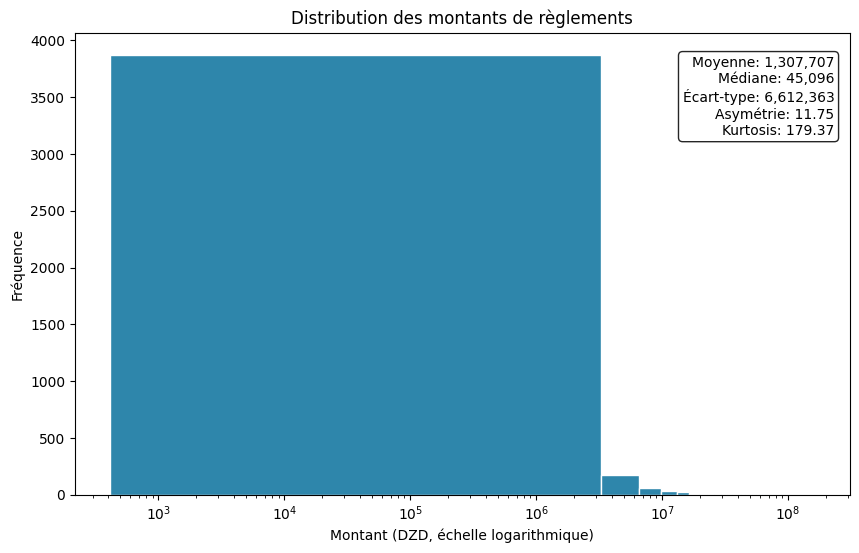

In [6]:
# CELL 5 — Distribution of claim payment amounts
eda_path = OUTPUT_DIR / '02_eda_results.txt'
amounts = merged['Montant_clean'].dropna()
amount_stats = {
    'count': amounts.count(),
    'mean': amounts.mean(),
    'median': amounts.median(),
    'std': amounts.std(),
    'skewness': amounts.skew(),
    'kurtosis': amounts.kurtosis(),
}

with open(eda_path, 'w', encoding='utf-8') as f:
    f.write('=== Résultats de l’analyse exploratoire ===\n\n')
    f.write('--- Statistiques des montants de règlements ---\n')
    labels_stats = {'count': 'nombre', 'mean': 'moyenne', 'median': 'médiane', 'std': 'écart-type', 'skewness': 'asymétrie', 'kurtosis': 'kurtosis'}
    for k, v in amount_stats.items():
        f.write(f'{labels_stats.get(k, k)}: {v}\n')

plt.figure(figsize=(10, 6))
plt.hist(amounts, bins=50, color='#2E86AB', edgecolor='white')
plt.xscale('log')
plt.title('Distribution des montants de règlements')
plt.xlabel('Montant (DZD, échelle logarithmique)')
plt.ylabel('Fréquence')
annotation = '\n'.join([
    f"Moyenne: {amount_stats['mean']:,.0f}",
    f"Médiane: {amount_stats['median']:,.0f}",
    f"Écart-type: {amount_stats['std']:,.0f}",
    f"Asymétrie: {amount_stats['skewness']:.2f}",
    f"Kurtosis: {amount_stats['kurtosis']:.2f}",
])
plt.annotate(annotation, xy=(0.98, 0.95), xycoords='axes fraction', ha='right', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
savefig(OUTPUT_DIR / 'fig01_montant_distribution.jpeg')


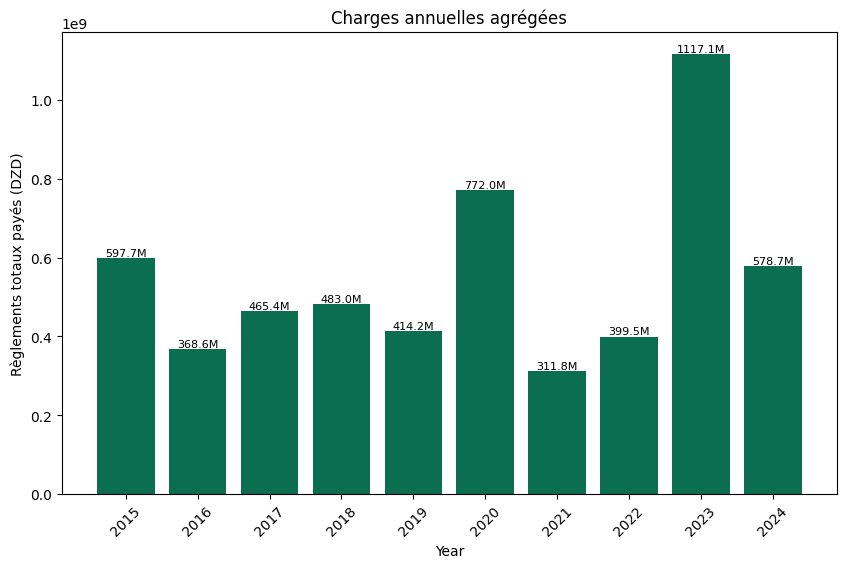

In [7]:
# CELL 6 — Charges annuelles agrégées
annual_losses = merged.groupby('ANNEE')['Montant_clean'].sum().sort_index()
analysis_objects['annual_losses'] = annual_losses

with open(eda_path, 'a', encoding='utf-8') as f:
    f.write('\n--- Charges annuelles agrégées ---\n')
    f.write(annual_losses.to_string())
    f.write('\n')

plt.figure(figsize=(10, 6))
bars = plt.bar(annual_losses.index.astype(str), annual_losses.values, color='#0B6E4F')
plt.title('Charges annuelles agrégées')
plt.xlabel('Year')
plt.ylabel('Règlements totaux payés (DZD)')
plt.xticks(rotation=45)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f'{h/1e6:.1f}M', ha='center', va='bottom', fontsize=8)
savefig(OUTPUT_DIR / 'fig02_annual_aggregate_losses.jpeg')


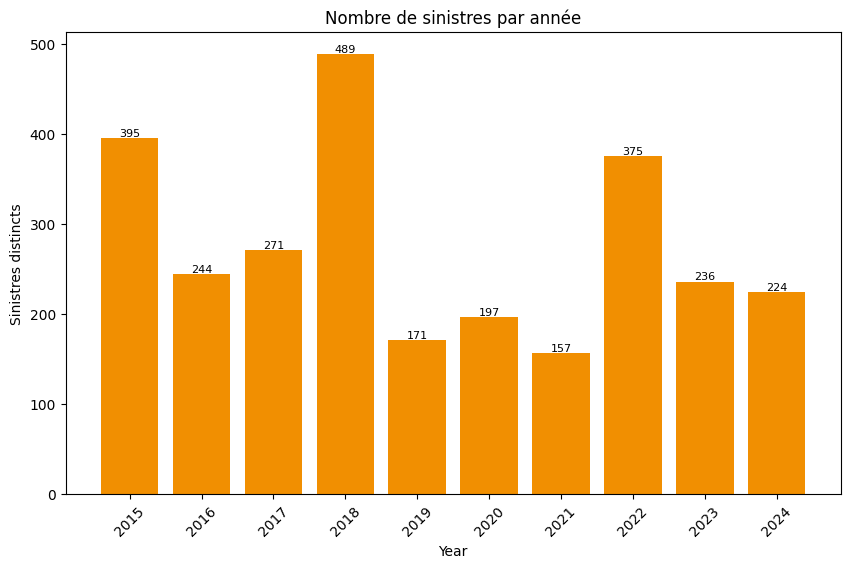

In [8]:
# CELL 7 — Nombre de sinistres par année
claim_count_by_year = merged.groupby('ANNEE')['Numéro_sinistre'].nunique().sort_index()
analysis_objects['claim_count_by_year'] = claim_count_by_year

with open(eda_path, 'a', encoding='utf-8') as f:
    f.write('\n--- Nombre de sinistres distincts par année ---\n')
    f.write(claim_count_by_year.to_string())
    f.write('\n')

plt.figure(figsize=(10, 6))
bars = plt.bar(claim_count_by_year.index.astype(str), claim_count_by_year.values, color='#F18F01')
plt.title('Nombre de sinistres par année')
plt.xlabel('Year')
plt.ylabel('Sinistres distincts')
plt.xticks(rotation=45)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f'{h:.0f}', ha='center', va='bottom', fontsize=8)
savefig(OUTPUT_DIR / 'fig03_claim_count_by_year.jpeg')


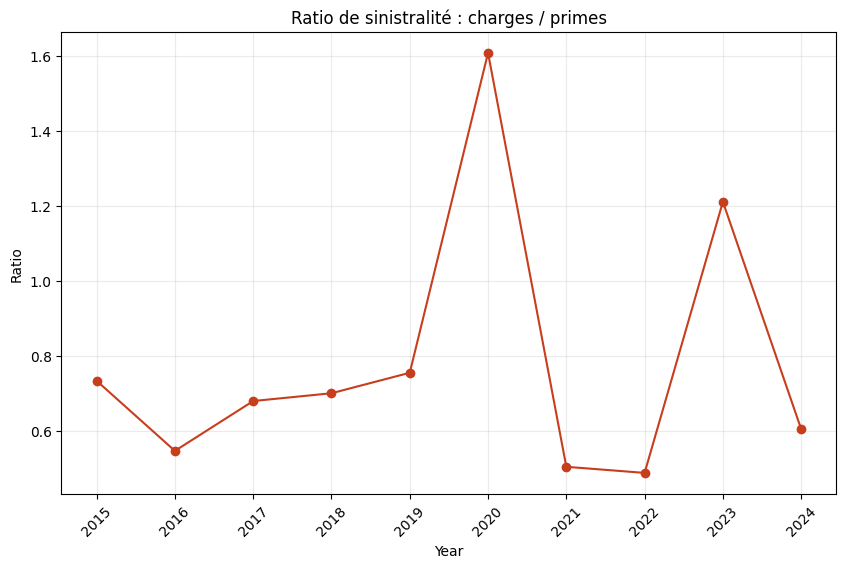

In [9]:
# CELL 8 — Sinistralité ratio
annual_premiums = contrats.groupby('EXERCICE')['Prime ttc'].sum().sort_index()
sin_ratio = pd.concat([annual_losses.rename('Losses'), annual_premiums.rename('Premiums')], axis=1)
sin_ratio['Sinistralite_ratio'] = sin_ratio['Losses'] / sin_ratio['Premiums']
analysis_objects['annual_premiums'] = annual_premiums
analysis_objects['sin_ratio'] = sin_ratio

with open(eda_path, 'a', encoding='utf-8') as f:
    f.write('\n--- Sinistralité ratio ---\n')
    f.write(sin_ratio.rename(columns={'Losses': 'Charges', 'Premiums': 'Primes', 'Sinistralite_ratio': 'Ratio_sinistralite'}).to_string())
    f.write('\n')

plt.figure(figsize=(10, 6))
plt.plot(sin_ratio.index.astype(str), sin_ratio['Sinistralite_ratio'], marker='o', color='#C73E1D')
plt.title('Ratio de sinistralité : charges / primes')
plt.xlabel('Year')
plt.ylabel('Ratio')
plt.grid(alpha=0.25)
plt.xticks(rotation=45)
savefig(OUTPUT_DIR / 'fig04_sinistralite_ratio.jpeg')


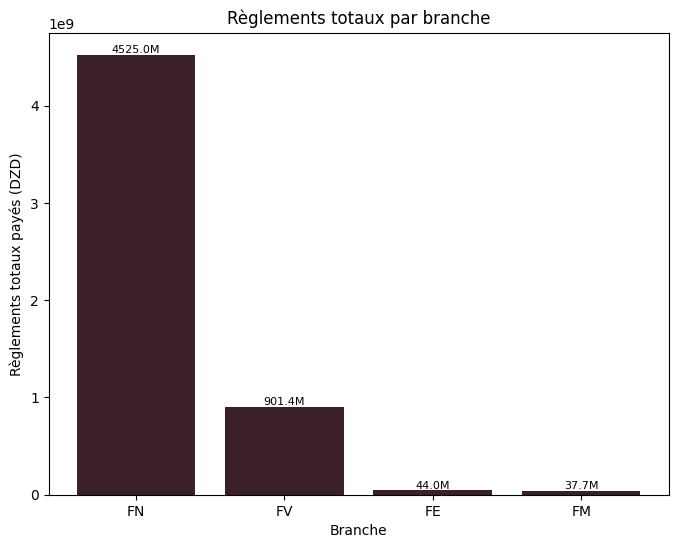

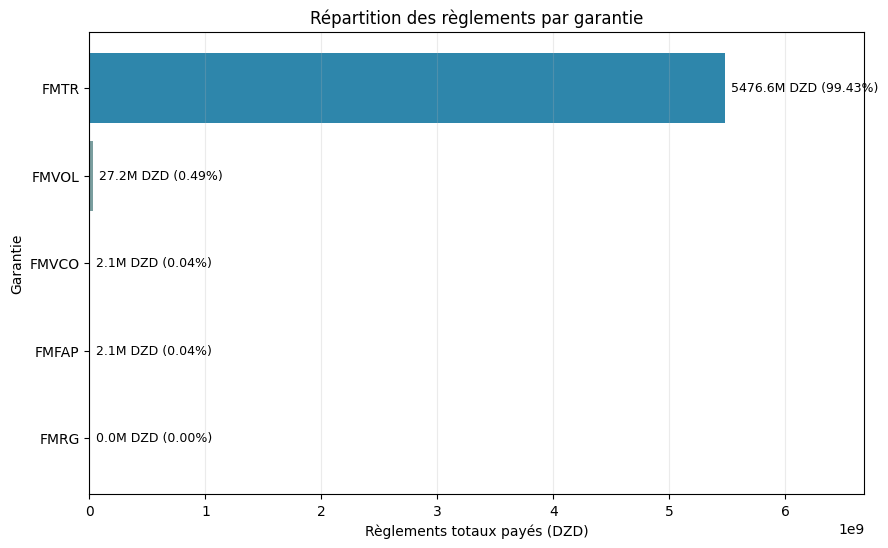

In [10]:
# CELL 9 — Charge par Branche et Garantie
loss_by_branche = merged.groupby('Branche_finale')['Montant_clean'].sum().sort_values(ascending=False)
loss_by_garantie = merged.groupby('Garantie')['Montant_clean'].sum().sort_values(ascending=False)
analysis_objects['loss_by_branche'] = loss_by_branche
analysis_objects['loss_by_garantie'] = loss_by_garantie

with open(eda_path, 'a', encoding='utf-8') as f:
    f.write('\n--- Charge par branche ---\n')
    f.write(loss_by_branche.to_string())
    f.write('\n\n--- Charge par garantie ---\n')
    f.write(loss_by_garantie.to_string())
    f.write('\n')

plt.figure(figsize=(8, 6))
bars = plt.bar(loss_by_branche.index.astype(str), loss_by_branche.values, color='#3B1F2B')
plt.title('Règlements totaux par branche')
plt.xlabel('Branche')
plt.ylabel('Règlements totaux payés (DZD)')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f'{h/1e6:.1f}M', ha='center', va='bottom', fontsize=8)
savefig(OUTPUT_DIR / 'fig05_loss_by_branche.jpeg')

# Le camembert devient illisible car FMTR concentre presque toute la charge.
# Un graphique horizontal garde les petites garanties lisibles.
garantie_plot = loss_by_garantie.sort_values(ascending=True)
total_garantie = garantie_plot.sum()
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#7A9E9F' if v < garantie_plot.max() else '#2E86AB' for v in garantie_plot.values]
bars = ax.barh(garantie_plot.index.astype(str), garantie_plot.values, color=colors)
ax.set_title('Répartition des règlements par garantie')
ax.set_xlabel('Règlements totaux payés (DZD)')
ax.set_ylabel('Garantie')
ax.grid(axis='x', alpha=0.25)
for bar, value in zip(bars, garantie_plot.values):
    pct = value / total_garantie * 100 if total_garantie else 0
    label = f'{value/1e6:.1f}M DZD ({pct:.2f}%)'
    ax.text(value + total_garantie * 0.01, bar.get_y() + bar.get_height()/2, label, va='center', fontsize=9)
ax.set_xlim(0, garantie_plot.max() * 1.22)
savefig(OUTPUT_DIR / 'fig06_loss_by_garantie.jpeg')


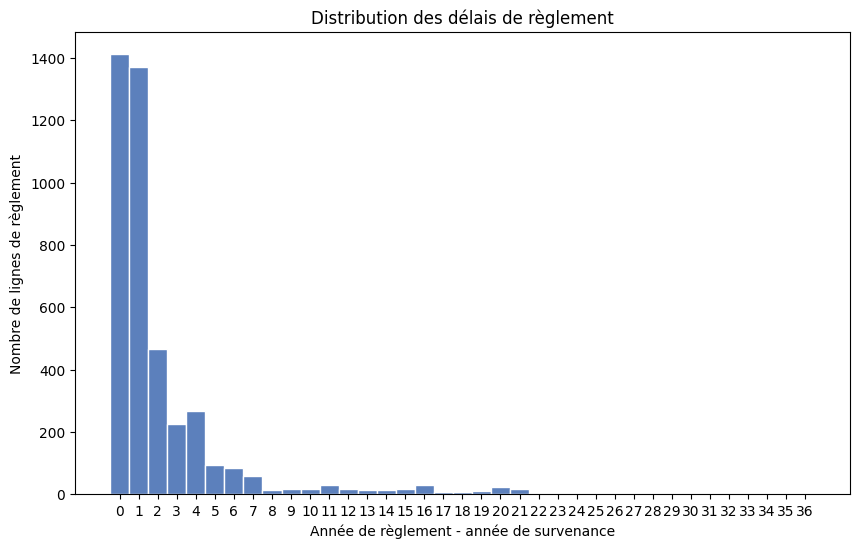

In [11]:
# CELL 10 — Settlement delay distribution
delays = merged['Delai_reglement'].dropna().astype(int)
analysis_objects['delays'] = delays

with open(eda_path, 'a', encoding='utf-8') as f:
    f.write('\n--- Statistiques des délais de règlement ---\n')
    f.write(delays.describe().rename(index={'count': 'nombre', 'mean': 'moyenne', 'std': 'écart-type', 'min': 'minimum', 'max': 'maximum'}).to_string())
    f.write('\n')

plt.figure(figsize=(10, 6))
max_delay = int(delays.max()) if len(delays) else 0
bins = np.arange(0, max_delay + 2) - 0.5 if max_delay >= 0 else 10
plt.hist(delays, bins=bins, color='#5C80BC', edgecolor='white')
plt.title('Distribution des délais de règlement')
plt.xlabel('Année de règlement - année de survenance')
plt.ylabel('Nombre de lignes de règlement')
plt.xticks(range(max_delay + 1))
savefig(OUTPUT_DIR / 'fig07_settlement_delay.jpeg')


## 3. Modélisation de la fréquence

In [12]:
# CELL 11 — Prepare frequency data
claim_counts = merged.groupby(['reference Police', 'ANNEE'])['Numéro_sinistre'].nunique().reset_index()
claim_counts.columns = ['Police', 'ANNEE', 'N_sinistres']

policy_années = contrats[['Police', 'EXERCICE', 'Branche']].dropna(subset=['Police', 'EXERCICE']).drop_duplicates()
policy_années = policy_années.rename(columns={'EXERCICE': 'ANNEE', 'Branche': 'Branche_policy'})
freq_df = policy_années.merge(claim_counts, on=['Police', 'ANNEE'], how='left')
freq_df['N_sinistres'] = freq_df['N_sinistres'].fillna(0).astype(int)
freq_df['ANNEE'] = pd.to_numeric(freq_df['ANNEE'], errors='coerce')
analysis_objects['freq_df'] = freq_df

freq_df.head()


,Police,ANNEE,Branche_policy,N_sinistres
0,101/FN/111/0/26,2015,FN,0
1,101/FN/112/0/25,2015,FN,0
2,101/FN/117/0/100,2015,FN,0
3,101/FN/117/0/101,2015,FN,0
4,101/FN/117/0/102,2015,FN,0


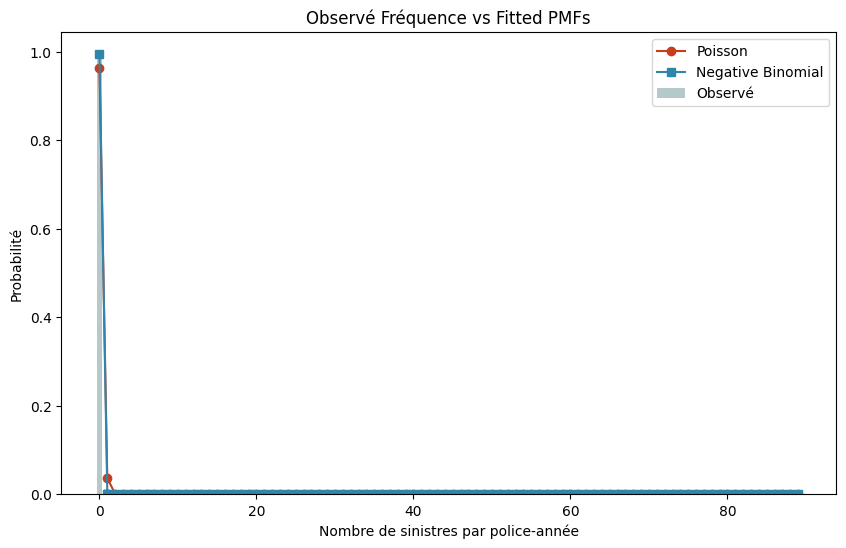

In [13]:
# CELL 12 — Fit Poisson vs Negative Binomial
freq_path = OUTPUT_DIR / '03_frequency_model_results.txt'
x = freq_df['N_sinistres'].dropna().astype(int).values
n_obs = len(x)
freq_results = []
lambda_hat = float(np.mean(x)) if n_obs else 0.0

# Poisson
try:
    ll_pois = poisson.logpmf(x, mu=lambda_hat).sum()
    aic_pois = safe_aic(ll_pois, 1)
    bic_pois = np.log(n_obs) * 1 - 2 * ll_pois if n_obs else np.inf
    ks_pois = kstest(x, poisson(mu=lambda_hat).cdf)
    freq_results.append({'model': 'Poisson', 'lambda': lambda_hat, 'r': np.nan, 'p': np.nan, 'loglik': ll_pois, 'AIC': aic_pois, 'BIC': bic_pois, 'KS_stat': ks_pois.statistic, 'KS_p': ks_pois.pvalue})
except Exception as e:
    freq_results.append({'model': 'Poisson', 'error': str(e)})

# Negative Binomial by method of moments
try:
    mean_x = np.mean(x)
    var_x = np.var(x, ddof=1) if n_obs > 1 else mean_x
    if var_x > mean_x and mean_x > 0:
        r_hat = mean_x ** 2 / (var_x - mean_x)
        p_hat = r_hat / (r_hat + mean_x)
        ll_nb = nbinom.logpmf(x, n=r_hat, p=p_hat).sum()
        aic_nb = safe_aic(ll_nb, 2)
        bic_nb = np.log(n_obs) * 2 - 2 * ll_nb if n_obs else np.inf
        ks_nb = kstest(x, nbinom(n=r_hat, p=p_hat).cdf)
        freq_results.append({'model': 'Negative Binomial', 'lambda': np.nan, 'r': r_hat, 'p': p_hat, 'loglik': ll_nb, 'AIC': aic_nb, 'BIC': bic_nb, 'KS_stat': ks_nb.statistic, 'KS_p': ks_nb.pvalue})
    else:
        freq_results.append({'model': 'Negative Binomial', 'error': 'Variance is not greater than mean; NB MOM fit not identified.'})
except Exception as e:
    freq_results.append({'model': 'Negative Binomial', 'error': str(e)})

freq_results_df = pd.DataFrame(freq_results)
valid_freq = freq_results_df.dropna(subset=['AIC']) if 'AIC' in freq_results_df.columns else pd.DataFrame()
best_frequency_model = valid_freq.sort_values('AIC').iloc[0].to_dict() if len(valid_freq) else {'model': 'Poisson', 'lambda': lambda_hat, 'AIC': np.nan}
analysis_objects['lambda_hat'] = lambda_hat
analysis_objects['freq_results_df'] = freq_results_df
analysis_objects['best_frequency_model'] = best_frequency_model

with open(freq_path, 'w', encoding='utf-8') as f:
    f.write('=== Résultats du modèle de fréquence ===\n\n')
    f.write('Unité : nombre de sinistres distincts par police-année.\n\n')
    f.write(freq_results_df.replace({'Negative Binomial': 'Binomiale négative'}).rename(columns={'model': 'modele'}).to_string(index=False))
    f.write('\n\n')
    f.write(f"Meilleur modèle de fréquence selon l’AIC: {str(best_frequency_model.get('model')).replace('Negative Binomial', 'Binomiale négative')}\n")

max_k = max(int(x.max()) if len(x) else 0, 5)
k = np.arange(0, max_k + 1)
plt.figure(figsize=(10, 6))
obs_counts = pd.Series(x).value_counts(normalize=True).reindex(k, fill_value=0)
plt.bar(k, obs_counts.values, width=0.75, alpha=0.55, label='Observé', color='#7A9E9F')
plt.plot(k, poisson.pmf(k, mu=lambda_hat), 'o-', label='Poisson', color='#C73E1D')
nb_row = freq_results_df[freq_results_df['model'].eq('Negative Binomial')]
if len(nb_row) and pd.notna(nb_row.iloc[0].get('r', np.nan)):
    plt.plot(k, nbinom.pmf(k, n=nb_row.iloc[0]['r'], p=nb_row.iloc[0]['p']), 's-', label='Negative Binomial', color='#2E86AB')
plt.title('Observé Fréquence vs Fitted PMFs')
plt.xlabel('Nombre de sinistres par police-année')
plt.ylabel('Probabilité')
plt.legend()
savefig(OUTPUT_DIR / 'fig08_frequency_fit.jpeg')


In [14]:
# CELL 13 — GLM frequency model (Poisson)
try:
    glm_df = freq_df.dropna(subset=['N_sinistres', 'ANNEE']).copy()
    glm_df['Branche_policy'] = glm_df['Branche_policy'].fillna('Unknown').astype(str)
    if glm_df['Branche_policy'].nunique() > 1:
        formula = 'N_sinistres ~ ANNEE + C(Branche_policy)'
    else:
        formula = 'N_sinistres ~ ANNEE'
    glm_model = smf.glm(formula=formula, data=glm_df, family=sm.families.Poisson(), offset=np.zeros(len(glm_df))).fit()
    analysis_objects['glm_frequency'] = glm_model
    with open(freq_path, 'a', encoding='utf-8') as f:
        f.write('\n--- Résumé du GLM de Poisson ---\n')
        f.write(glm_model.summary().as_text())
except Exception as e:
    with open(freq_path, 'a', encoding='utf-8') as f:
        f.write('\n--- Poisson GLM failed ---\n')
        f.write(str(e) + '\n')


In [15]:
# CELL 13b — Balanced Logistic Regression: Claim Occurrence Prediction (v2)
# Prepare policy-year dataset for logistic regression with improved class balancing and feature engineering.
# Binary outcome: has at least one claim payment (1) vs. no claim (0) in a given policy-year.

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix, brier_score_loss

# Build policy-year panel using already loaded data
print("Building policy-year panel...")
panel = contrats[['Police', 'EXERCICE', 'Branche', 'Type Client', 'prime nette', 'Production', 'Capital assuré']].copy()
panel.columns = ['Police', 'ANNEE', 'Branche', 'Type_Client', 'Prime_nette', 'Production', 'Capital']
panel = panel.dropna(subset=['Police', 'ANNEE']).drop_duplicates()

# Binary outcome: has at least one positive payment in this policy-year
claims_py = (
    reglements
    .groupby(['reference Police', 'ANNEE'])['Montant']
    .agg(N_payments='count', Total_paid='sum')
    .reset_index()
    .rename(columns={'reference Police': 'Police'})
)
claims_py['Has_claim'] = 1

panel = panel.merge(claims_py[['Police', 'ANNEE', 'Has_claim', 'N_payments', 'Total_paid']],
                    on=['Police', 'ANNEE'], how='left')
panel['Has_claim']  = panel['Has_claim'].fillna(0).astype(int)
panel['N_payments'] = panel['N_payments'].fillna(0).astype(int)
panel['Total_paid'] = panel['Total_paid'].fillna(0).astype(float)

panel['ANNEE'] = pd.to_numeric(panel['ANNEE'], errors='coerce')
panel = panel[panel['ANNEE'].between(STUDY_START, STUDY_END, inclusive='both')].copy()

# Feature engineering
panel = panel.dropna(subset=['Branche', 'Type_Client'])
panel['Branche']    = panel['Branche'].astype(str).str.strip()
panel['Type_Client']= panel['Type_Client'].astype(str).str.strip()

# Fill numeric NAs with medians
for col in ['Prime_nette', 'Production', 'Capital']:
    panel[col] = pd.to_numeric(panel[col], errors='coerce')
    panel[col] = panel[col].fillna(panel[col].median())
    panel[col] = panel[col].clip(lower=0)

# Log-transforms
panel['log_prime']      = np.log1p(panel['Prime_nette'])
panel['log_production'] = np.log1p(panel['Production'])
panel['log_capital']    = np.log1p(panel['Capital'])

# Year-centered
year_mean = panel['ANNEE'].mean()
panel['ANNEE_c'] = panel['ANNEE'] - year_mean
panel['log_prime_x_annee'] = panel['log_prime'] * panel['ANNEE_c']

# One-hot encode categoricals
panel_enc = pd.get_dummies(
    panel[['log_prime', 'log_production', 'log_capital',
           'ANNEE_c', 'log_prime_x_annee',
           'Branche', 'Type_Client', 'Has_claim']],
    columns=['Branche', 'Type_Client'],
    drop_first=True
)

# Convert bool dummies to int
bool_cols = panel_enc.select_dtypes(include='bool').columns
panel_enc[bool_cols] = panel_enc[bool_cols].astype(int)

feature_cols = [c for c in panel_enc.columns if c != 'Has_claim']
X_raw = panel_enc[feature_cols].values.astype(float)
y     = panel_enc['Has_claim'].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Fit balanced logistic regression
print("Fitting balanced logistic regression (class_weight='balanced')...")
clf = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    C=1.0,
    random_state=42
)
clf.fit(X_scaled, y)

y_prob = clf.predict_proba(X_scaled)[:, 1]

# Optimal threshold via Youden's J
fpr, tpr, thresholds = roc_curve(y, y_prob)
j_scores = tpr - fpr
best_idx  = np.argmax(j_scores)
best_thresh = thresholds[best_idx]
roc_auc_val = auc(fpr, tpr)

y_pred_opt = (y_prob >= best_thresh).astype(int)

# Stratified 5-fold cross-validation
print("Running 5-fold stratified cross-validation...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(clf, X_scaled, y, cv=cv, scoring='roc_auc')
cv_ap  = cross_val_score(clf, X_scaled, y, cv=cv, scoring='average_precision')

# Save model & data to analysis_objects for compatibility
analysis_objects['glm_logit'] = clf
analysis_objects['glm_data'] = panel_enc
analysis_objects['X_glm'] = X_scaled
analysis_objects['y_glm'] = y
analysis_objects['y_prob_glm'] = y_prob
analysis_objects['best_thresh_glm'] = best_thresh
analysis_objects['feature_cols_glm'] = feature_cols

# Write summary file
result_path = OUTPUT_DIR / '03d_logistic_v2_results.txt'
with open(result_path, 'w', encoding='utf-8') as f:
    f.write("=== Régression Logistique Améliorée — CAAT Transport (v2) ===\n\n")
    f.write(f"Période : {STUDY_START}–{STUDY_END}\n")
    f.write(f"Observations totales (police-année) : {len(y)}\n")
    f.write(f"Cas positifs (Has_claim=1) : {y.sum()} ({y.mean()*100:.2f}%)\n")
    f.write(f"Cas négatifs (Has_claim=0) : {(y==0).sum()}\n\n")
    f.write("Variables explicatives :\n")
    for col in feature_cols:
        f.write(f"  - {col}\n")
    f.write("\nMéthode : Régression logistique avec class_weight='balanced'\n")
    f.write("Solveur : L-BFGS, C=1.0, max_iter=1000\n\n")
    f.write("=== Performance globale ===\n\n")
    f.write(f"AUC-ROC (train)              : {roc_auc_val:.4f}\n")
    f.write(f"Brier Score (lower=better)    : {brier_score_loss(y, y_prob):.4f}\n\n")
    f.write("=== Validation croisée 5-fold ===\n\n")
    f.write(f"AUC moyen : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}\n")
    f.write(f"AP moyen  : {cv_ap.mean():.4f} ± {cv_ap.std():.4f}\n\n")

print(f"Model trained. Train AUC: {roc_auc_val:.4f}, Optimal threshold: {best_thresh:.4f}")


Building policy-year panel...
Fitting balanced logistic regression (class_weight='balanced')...
Running 5-fold stratified cross-validation...
Model trained. Train AUC: 0.8918, Optimal threshold: 0.5110


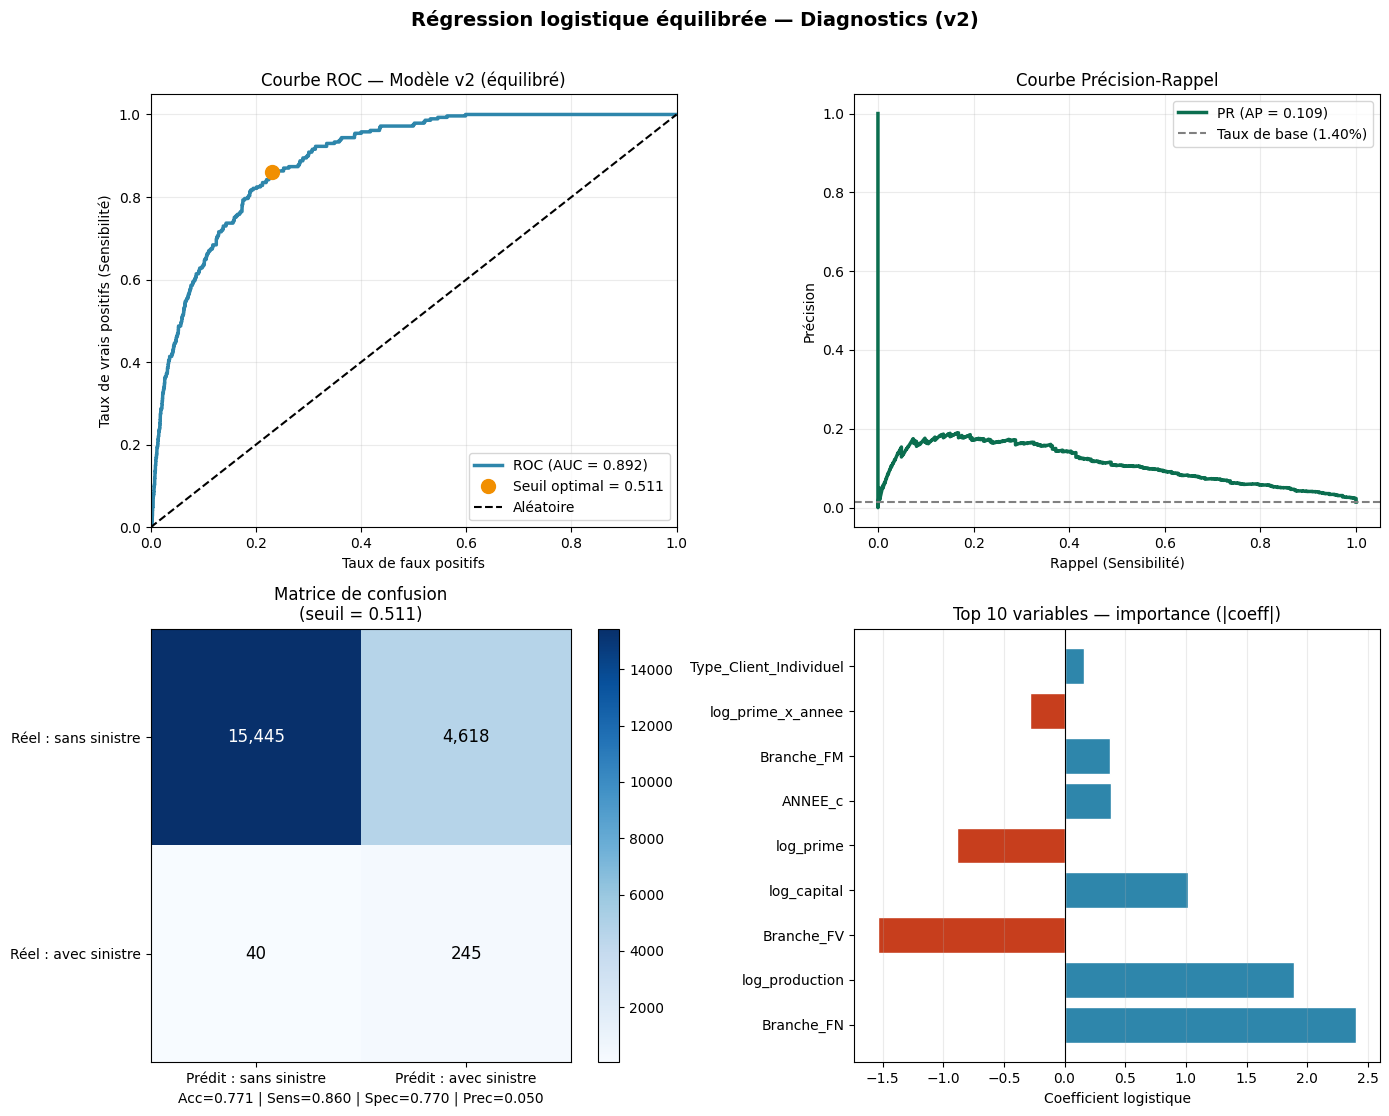

fig18 saved.


In [16]:
# CELL 13c — Logistic Regression Visualization & Diagnostics (v2)
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix

clf = analysis_objects['glm_logit']
X_scaled = analysis_objects['X_glm']
y = analysis_objects['y_glm']
y_prob = analysis_objects['y_prob_glm']
best_thresh = analysis_objects['best_thresh_glm']
feature_cols = list(analysis_objects['feature_cols_glm'])

fpr, tpr, thresholds = roc_curve(y, y_prob)
best_idx = np.argmax(tpr - fpr)
roc_auc_val = auc(fpr, tpr)
y_pred_opt = (y_prob >= best_thresh).astype(int)
cm = confusion_matrix(y, y_pred_opt)
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / len(y)
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
avg_prec = average_precision_score(y, y_prob)

# Figure 18: 4-panel diagnostic
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# (a) ROC Curve
axes[0, 0].plot(fpr, tpr, color='#2E86AB', lw=2.5, label=f"ROC (AUC = {roc_auc_val:.3f})")
axes[0, 0].plot(fpr[best_idx], tpr[best_idx], 'o', color='#F18F01', markersize=10, label=f"Seuil optimal = {best_thresh:.3f}")
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1.5, label="Aléatoire")
axes[0, 0].set_xlim([0, 1])
axes[0, 0].set_ylim([0, 1.05])
axes[0, 0].set_xlabel("Taux de faux positifs")
axes[0, 0].set_ylabel("Taux de vrais positifs (Sensibilité)")
axes[0, 0].set_title("Courbe ROC — Modèle v2 (équilibré)")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.25)

# (b) Precision-Recall Curve
prec_arr, rec_arr, _ = precision_recall_curve(y, y_prob)
axes[0, 1].plot(rec_arr, prec_arr, color='#0B6E4F', lw=2.5, label=f"PR (AP = {avg_prec:.3f})")
axes[0, 1].axhline(y.mean(), color='gray', linestyle='--', lw=1.5, label=f"Taux de base ({y.mean()*100:.2f}%)")
axes[0, 1].set_xlabel("Rappel (Sensibilité)")
axes[0, 1].set_ylabel("Précision")
axes[0, 1].set_title("Courbe Précision-Rappel")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.25)

# (c) Confusion Matrix Heatmap
im = axes[1, 0].imshow(cm, cmap='Blues', aspect='auto')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_yticks([0, 1])
axes[1, 0].set_xticklabels(['Prédit : sans sinistre', 'Prédit : avec sinistre'])
axes[1, 0].set_yticklabels(['Réel : sans sinistre', 'Réel : avec sinistre'])
axes[1, 0].set_title(f"Matrice de confusion\n(seuil = {best_thresh:.3f})")
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, f"{cm[i,j]:,}", ha='center', va='center', color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=12)
plt.colorbar(im, ax=axes[1, 0])
axes[1, 0].set_xlabel(f"Acc={accuracy:.3f} | Sens={sensitivity:.3f} | Spec={specificity:.3f} | Prec={precision:.3f}")

# (d) Top 10 Features by absolute coefficient
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': clf.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
coef_top = coef_df.head(10)
colors_bar = ['#2E86AB' if c > 0 else '#C73E1D' for c in coef_top['Coefficient']]
axes[1, 1].barh(coef_top['Feature'], coef_top['Coefficient'], color=colors_bar, edgecolor='white')
axes[1, 1].axvline(0, color='black', linewidth=0.8)
axes[1, 1].set_xlabel("Coefficient logistique")
axes[1, 1].set_title("Top 10 variables — importance (|coeff|)")
axes[1, 1].grid(axis='x', alpha=0.25)

plt.suptitle("Régression logistique équilibrée — Diagnostics (v2)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
savefig(OUTPUT_DIR / 'fig18_logistic_v2_diagnostics.jpeg')
print("fig18 saved.")


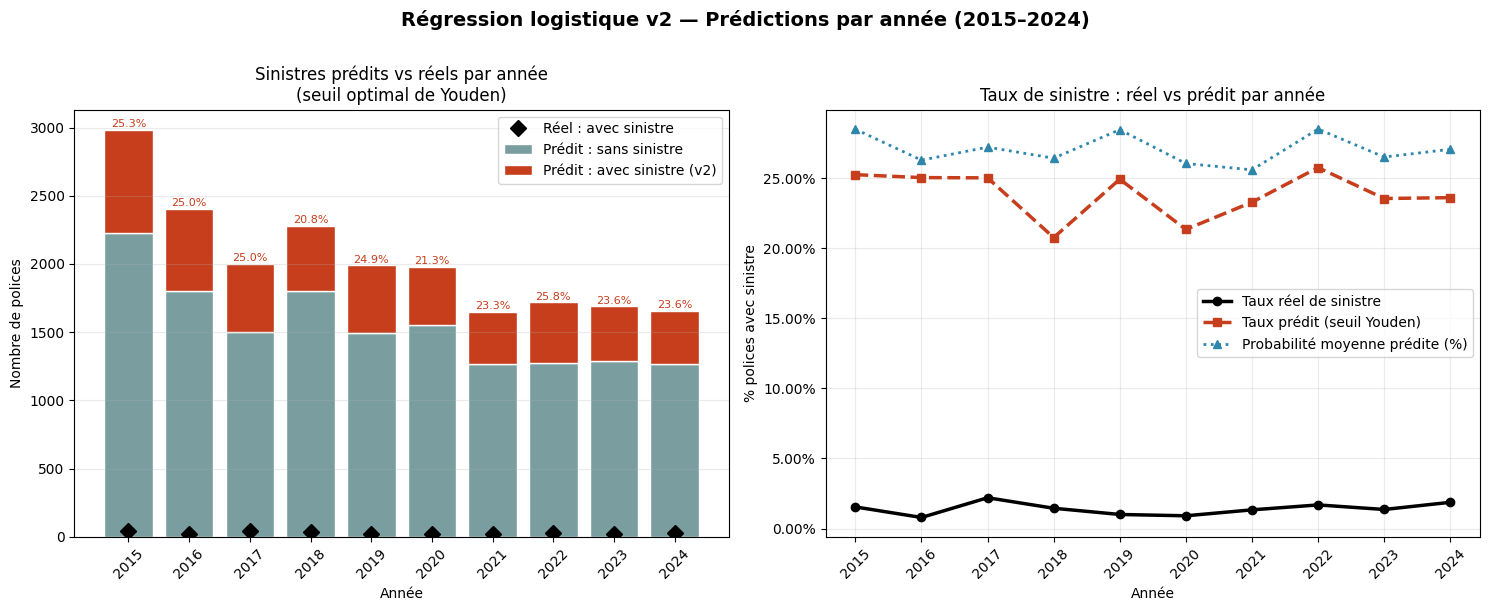

fig19 saved.


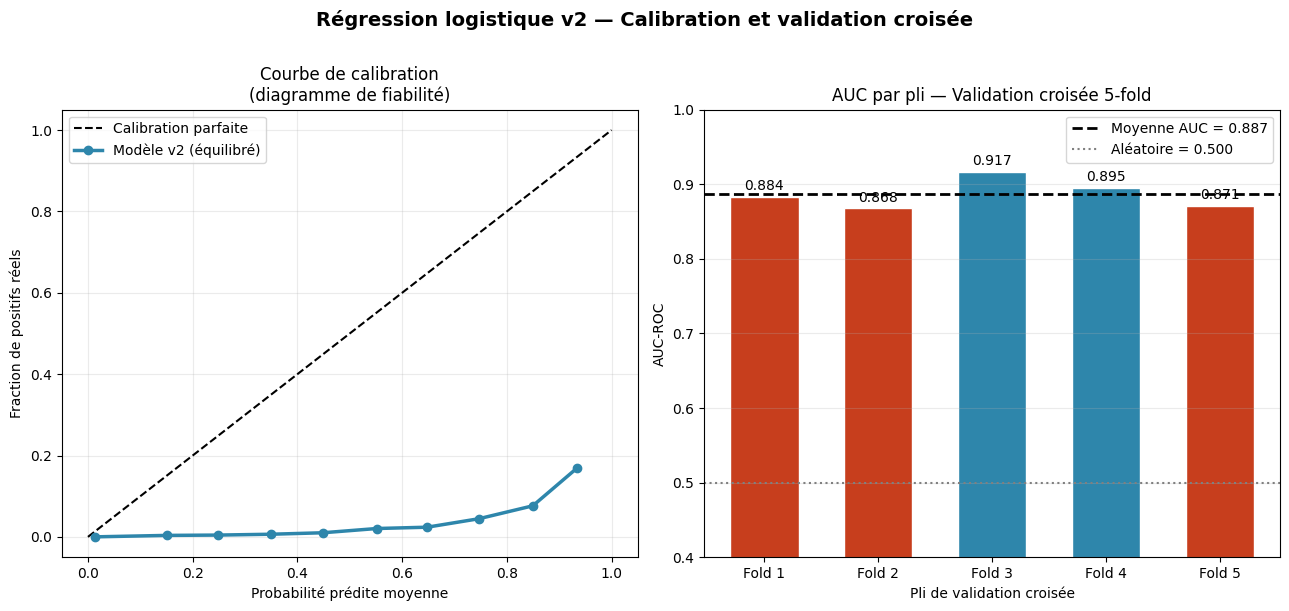

fig20 saved.


In [17]:
# CELL 13d — Logistic Regression: Predictions by Year & Calibration (v2)
import matplotlib.ticker as mticker
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score

clf = analysis_objects['glm_logit']
panel_enc = analysis_objects['glm_data']
X_scaled = analysis_objects['X_glm']
y = analysis_objects['y_glm']
y_prob = analysis_objects['y_prob_glm']
best_thresh = analysis_objects['best_thresh_glm']

panel_enc2 = panel_enc.copy()
panel_enc2['y_prob'] = y_prob
panel_enc2['y_pred_opt'] = (y_prob >= best_thresh).astype(int)
panel_enc2['ANNEE'] = contrats.loc[panel_enc.index, 'EXERCICE'].values  # Retrieve original years

yr_agg = panel_enc2.groupby('ANNEE').agg(
    N_total=('Has_claim', 'count'),
    N_actual_claim=('Has_claim', 'sum'),
    N_pred_claim=('y_pred_opt', 'sum'),
    Avg_prob=('y_prob', 'mean')
).reset_index()
yr_agg['Pct_actual'] = yr_agg['N_actual_claim'] / yr_agg['N_total'] * 100
yr_agg['Pct_predicted'] = yr_agg['N_pred_claim'] / yr_agg['N_total'] * 100
yr_agg = yr_agg.sort_values('ANNEE')

# Figure 19: per-year actual vs predicted positives
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
x_labels = yr_agg['ANNEE'].astype(int).astype(str).tolist()

axes[0].bar(x_labels, yr_agg['N_total'] - yr_agg['N_pred_claim'], label="Prédit : sans sinistre", color='#7A9E9F', edgecolor='white')
axes[0].bar(x_labels, yr_agg['N_pred_claim'], bottom=yr_agg['N_total'] - yr_agg['N_pred_claim'], label="Prédit : avec sinistre (v2)", color='#C73E1D', edgecolor='white')
axes[0].plot(x_labels, yr_agg['N_actual_claim'], 'D', color='black', markersize=8, label="Réel : avec sinistre", zorder=5)
axes[0].set_title("Sinistres prédits vs réels par année\n(seuil optimal de Youden)")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Nombre de polices")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.25)
for i, (bar, pct) in enumerate(zip(axes[0].patches[len(x_labels):], yr_agg['Pct_predicted'])):
    h = bar.get_height() + bar.get_y()
    if pct > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 5, f"{pct:.1f}%", ha='center', va='bottom', fontsize=8, color='#C73E1D')

axes[1].plot(x_labels, yr_agg['Pct_actual'], marker='o', color='black', linewidth=2.5, label="Taux réel de sinistre")
axes[1].plot(x_labels, yr_agg['Pct_predicted'], marker='s', color='#C73E1D', linewidth=2.5, linestyle='--', label="Taux prédit (seuil Youden)")
axes[1].plot(x_labels, yr_agg['Avg_prob'] * 100, marker='^', color='#2E86AB', linewidth=2, linestyle=':', label="Probabilité moyenne prédite (%)")
axes[1].set_title("Taux de sinistre : réel vs prédit par année")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("% polices avec sinistre")
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.25)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))

plt.suptitle("Régression logistique v2 — Prédictions par année (2015–2024)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
savefig(OUTPUT_DIR / 'fig19_logistic_v2_by_year.jpeg')
print("fig19 saved.")

# Figure 20: Calibration and CV AUC
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fraction_of_pos, mean_predicted_value = calibration_curve(y, y_prob, n_bins=10)
axes[0].plot([0, 1], [0, 1], 'k--', label="Calibration parfaite")
axes[0].plot(mean_predicted_value, fraction_of_pos, marker='o', color='#2E86AB', linewidth=2.5, label="Modèle v2 (équilibré)")
axes[0].set_xlabel("Probabilité prédite moyenne")
axes[0].set_ylabel("Fraction de positifs réels")
axes[0].set_title("Courbe de calibration\n(diagramme de fiabilité)")
axes[0].legend()
axes[0].grid(alpha=0.25)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(clf, X_scaled, y, cv=cv, scoring='roc_auc')
fold_labels = [f"Fold {i+1}" for i in range(len(cv_auc))]
bar_colors = ['#2E86AB' if v >= cv_auc.mean() else '#C73E1D' for v in cv_auc]
axes[1].bar(fold_labels, cv_auc, color=bar_colors, edgecolor='white', width=0.6)
axes[1].axhline(cv_auc.mean(), color='black', linestyle='--', linewidth=2, label=f"Moyenne AUC = {cv_auc.mean():.3f}")
axes[1].axhline(0.5, color='gray', linestyle=':', linewidth=1.5, label="Aléatoire = 0.500")
axes[1].set_ylim([0.4, 1.0])
axes[1].set_xlabel("Pli de validation croisée")
axes[1].set_ylabel("AUC-ROC")
axes[1].set_title("AUC par pli — Validation croisée 5-fold")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.25)
for i, v in enumerate(cv_auc):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha='center', va='bottom', fontsize=10)

plt.suptitle("Régression logistique v2 — Calibration et validation croisée", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
savefig(OUTPUT_DIR / 'fig20_logistic_v2_calibration.jpeg')
print("fig20 saved.")


## 4. Modélisation de la sévérité

In [18]:
# CELL 14 — Fit Log-Normal, Gamma, and Pareto claim severity distributions
sev_path = OUTPUT_DIR / '04_severity_model_results.txt'
sev_data = claim_severity_df['Claim_amount'].dropna().astype(float).values
severity_results = []
fitted_severity = {}

for name, dist, k_params in [
    ('LogNorm', lognorm, 2),
    ('Gamma', gamma_dist, 2),
    ('Pareto', pareto, 2),
]:
    try:
        params = dist.fit(sev_data, floc=0)
        ll = np.sum(dist.logpdf(sev_data, *params))
        aic = safe_aic(ll, k_params)
        ks = kstest(sev_data, dist.cdf, args=params)
        severity_results.append({'distribution': name, 'params': params, 'loglik': ll, 'AIC': aic, 'KS_stat': ks.statistic, 'KS_p': ks.pvalue})
        fitted_severity[name] = {'dist': dist, 'params': params, 'AIC': aic}
    except Exception as e:
        severity_results.append({'distribution': name, 'params': None, 'loglik': np.nan, 'AIC': np.inf, 'KS_stat': np.nan, 'KS_p': np.nan, 'error': str(e)})

severity_results_df = pd.DataFrame(severity_results)
best_severity_name = severity_results_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['AIC']).sort_values('AIC').iloc[0]['distribution'] if len(severity_results_df.dropna(subset=['AIC'])) else None
best_severity = fitted_severity.get(best_severity_name)
analysis_objects['severity_results_df'] = severity_results_df
analysis_objects['fitted_severity'] = fitted_severity
analysis_objects['best_severity_name'] = best_severity_name
analysis_objects['best_severity'] = best_severity
analysis_objects['severity_unit'] = 'claim-level paid amount'

severity_results_df


,distribution,params,loglik,AIC,KS_stat,KS_p
0,LogNorm,"(2.2111578824454994, 0, 105093.60376419785)",-32233.643996,64471.287992,0.118690,3.518479e-29
1,Gamma,"(0.2313297131137787, 0, 10175397.97084686)",-33279.187138,66562.374276,0.269896,4.852077e-151
2,Pareto,"(0.21551713851586746, 0, 1014.96)",-32987.732404,65979.464807,0.308933,8.103313e-199


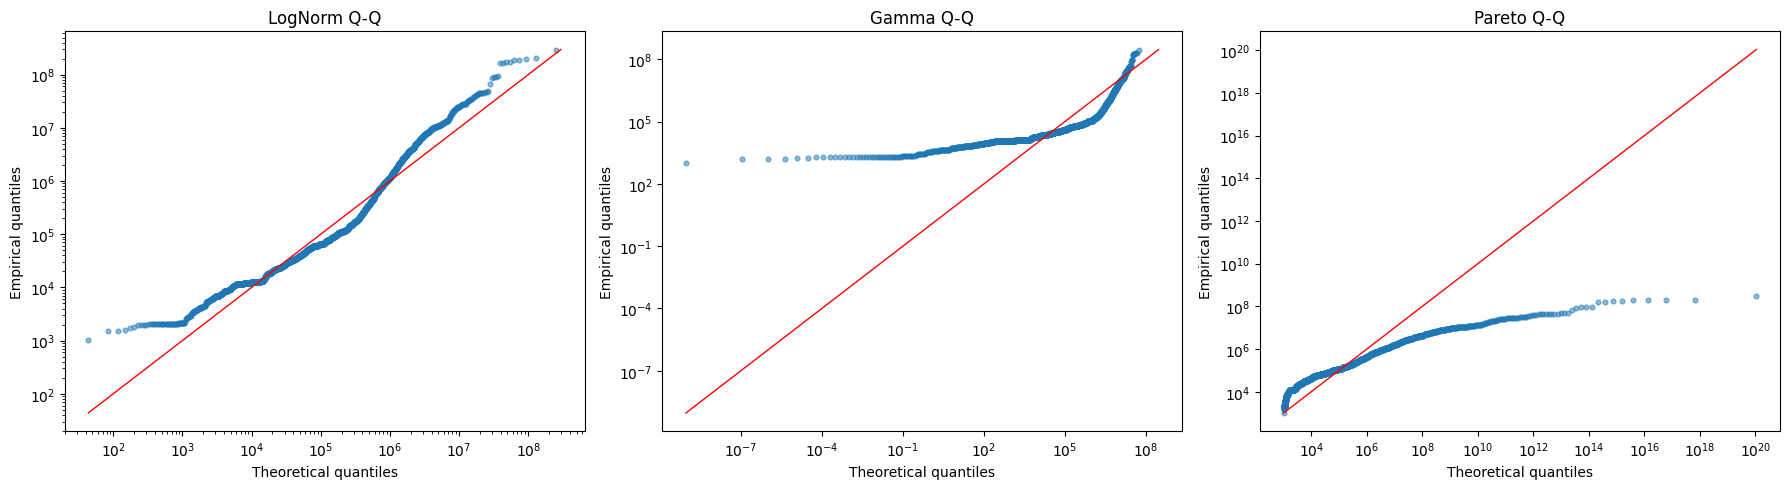

In [19]:
# CELL 15 — Q-Q plots for severity fits
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
probs = (np.arange(1, len(sev_data) + 1) - 0.5) / len(sev_data)
empirical_sorted = np.sort(sev_data)

for ax, name in zip(axes, ['LogNorm', 'Gamma', 'Pareto']):
    fit = fitted_severity.get(name)
    if fit is None:
        ax.text(0.5, 0.5, f'{name} fit failed', ha='center', va='center')
        ax.set_title(f'{name} Q-Q')
        continue
    theoretical = fit['dist'].ppf(probs, *fit['params'])
    ax.scatter(theoretical, empirical_sorted, s=12, alpha=0.5)
    mn = np.nanmin([theoretical.min(), empirical_sorted.min()])
    mx = np.nanmax([theoretical.max(), empirical_sorted.max()])
    ax.plot([mn, mx], [mn, mx], color='red', linewidth=1)
    ax.set_title(f'{name} Q-Q')
    ax.set_xlabel('Theoretical quantiles')
    ax.set_ylabel('Empirical quantiles')
    ax.set_xscale('log')
    ax.set_yscale('log')

plt.tight_layout()
savefig(OUTPUT_DIR / 'fig09_severity_qq_plots.jpeg')


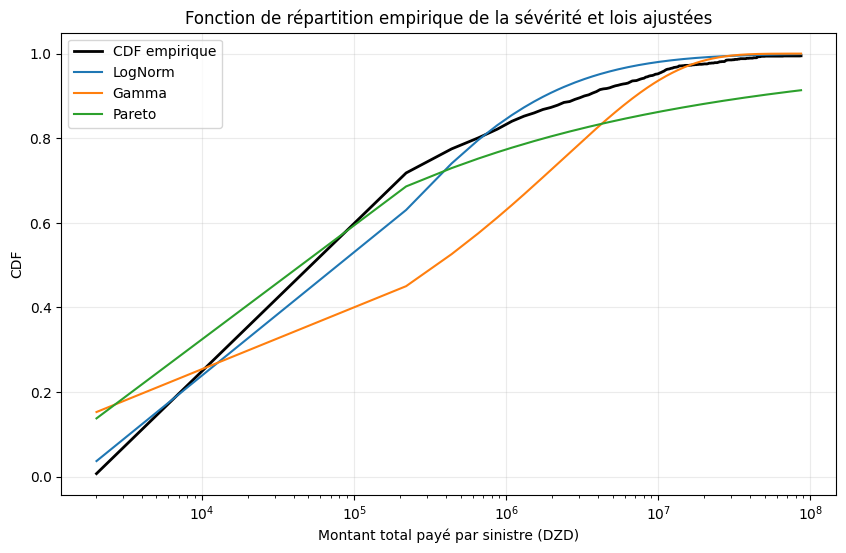

In [20]:
# CELL 16 — Save severity results and CDF comparison
with open(sev_path, 'w', encoding='utf-8') as f:
    f.write('=== Résultats du modèle de sévérité ===\n\n')
    f.write('Unité : montant total payé par sinistre, agrégé à partir des lignes de règlements positives.\n\n')
    f.write(severity_results_df.rename(columns={'distribution': 'loi', 'params': 'parametres', 'loglik': 'log_vraisemblance'}).to_string(index=False))
    f.write('\n\n')
    f.write(f'Meilleur modèle de sévérité selon l’AIC: {best_severity_name}\n')

x_grid = np.linspace(np.percentile(sev_data, 0.5), np.percentile(sev_data, 99.5), 400)
ecdf_y = np.searchsorted(np.sort(sev_data), x_grid, side='right') / len(sev_data)
plt.figure(figsize=(10, 6))
plt.plot(x_grid, ecdf_y, label='CDF empirique', color='black', linewidth=2)
for name, fit in fitted_severity.items():
    try:
        plt.plot(x_grid, fit['dist'].cdf(x_grid, *fit['params']), label=name)
    except Exception:
        pass
plt.title('Fonction de répartition empirique de la sévérité et lois ajustées')
plt.xlabel('Montant total payé par sinistre (DZD)')
plt.ylabel('CDF')
plt.xscale('log')
plt.legend()
plt.grid(alpha=0.25)
savefig(OUTPUT_DIR / 'fig10_severity_cdf_comparison.jpeg')


## 5. Modèle de perte agrégée — Monte Carlo

In [21]:
# CELL 17 — Aggregate loss simulation
np.random.seed(42)
N_sim = 50_000

# Annual claim count basis: distinct sinistres per calendar year.
annual_claim_counts = merged.groupby('ANNEE')['Numéro_sinistre'].nunique().dropna().astype(int)
annual_lambda_hat = float(annual_claim_counts.mean()) if len(annual_claim_counts) else max(lambda_hat, 0.0)
annual_count_var = float(annual_claim_counts.var(ddof=1)) if len(annual_claim_counts) > 1 else annual_lambda_hat

use_nb_aggregate = annual_count_var > annual_lambda_hat and annual_lambda_hat > 0
if use_nb_aggregate:
    agg_r = annual_lambda_hat ** 2 / (annual_count_var - annual_lambda_hat)
    agg_p = agg_r / (agg_r + annual_lambda_hat)
else:
    agg_r, agg_p = np.nan, np.nan

# If the best parametric severity model is rejected by KS, use an empirical
# bootstrap for aggregate loss. This keeps the Monte Carlo on the observed claim
# severity scale while preserving the distribution-fit diagnostics above.
best_sev_row = severity_results_df[severity_results_df['distribution'].eq(best_severity_name)]
best_sev_ks_p = float(best_sev_row['KS_p'].iloc[0]) if len(best_sev_row) else 0.0
use_empirical_severity = (best_sev_ks_p < 0.05) or (best_severity is None)
aggregate_severity_model = 'Bootstrap empirique de la sévérité par sinistre' if use_empirical_severity else best_severity_name
empirical_claim_severity = claim_severity_df['Claim_amount'].dropna().astype(float).values

aggregate_losses = []
for _ in range(N_sim):
    if use_nb_aggregate:
        n = nbinom.rvs(n=agg_r, p=agg_p)
    else:
        n = poisson.rvs(mu=annual_lambda_hat)
    if n > 0:
        if use_empirical_severity:
            losses = np.random.choice(empirical_claim_severity, size=n, replace=True)
        else:
            losses = best_severity['dist'].rvs(*best_severity['params'], size=n)
        aggregate_losses.append(losses.sum())
    else:
        aggregate_losses.append(0.0)
aggregate_losses = np.array(aggregate_losses)

analysis_objects['aggregate_losses'] = aggregate_losses
analysis_objects['annual_lambda_hat'] = annual_lambda_hat
analysis_objects['aggregate_frequency_model'] = {'model': 'Negative Binomial' if use_nb_aggregate else 'Poisson', 'lambda': annual_lambda_hat, 'r': agg_r, 'p': agg_p}
analysis_objects['aggregate_severity_model'] = aggregate_severity_model
analysis_objects['use_empirical_severity'] = use_empirical_severity


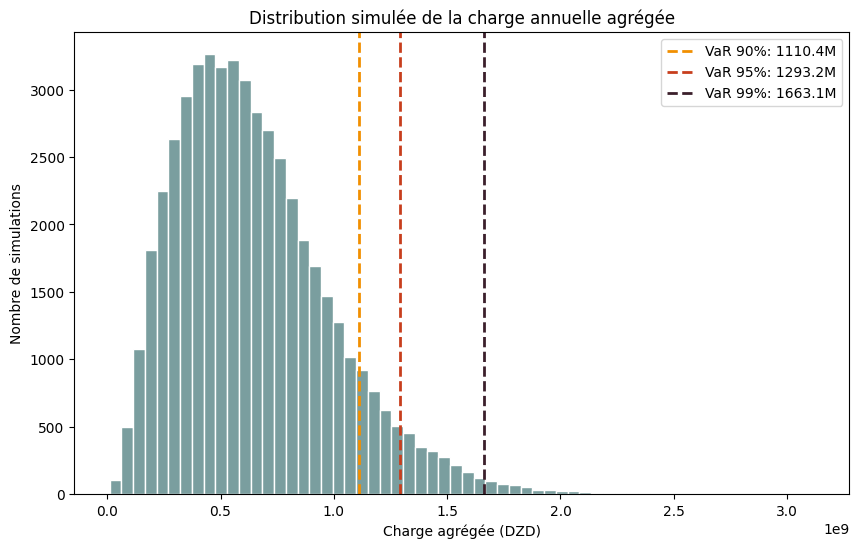

In [22]:
# CELL 18 — Risk measures and aggregate loss chart
agg_path = OUTPUT_DIR / '05_aggregate_loss_results.txt'
var90, var95, var99 = np.percentile(aggregate_losses, [90, 95, 99])
tvar95 = aggregate_losses[aggregate_losses > var95].mean() if np.any(aggregate_losses > var95) else var95
tvar99 = aggregate_losses[aggregate_losses > var99].mean() if np.any(aggregate_losses > var99) else var99
agg_measures = {
    'E[S]': aggregate_losses.mean(),
    'Var[S]': aggregate_losses.var(ddof=1),
    'Std[S]': aggregate_losses.std(ddof=1),
    'VaR 90%': var90,
    'VaR 95%': var95,
    'VaR 99%': var99,
    'TVaR 95%': tvar95,
    'TVaR 99%': tvar99,
}
analysis_objects['agg_measures'] = agg_measures

with open(agg_path, 'w', encoding='utf-8') as f:
    f.write('=== Résultats Monte Carlo de la charge agrégée ===\n\n')
    f.write(f"Modèle de fréquence utilisé : {analysis_objects['aggregate_frequency_model']}\n")
    f.write(f"Modèle de sévérité utilisé pour la simulation : {analysis_objects['aggregate_severity_model']}\n")
    f.write(f'Meilleur modèle paramétrique de sévérité : {best_severity_name}\n')
    f.write(f'Simulations: {N_sim}\n\n')
    for k, v in agg_measures.items():
        f.write(f'{k}: {v:,.2f} DZD\n')

plt.figure(figsize=(10, 6))
plt.hist(aggregate_losses, bins=60, color='#7A9E9F', edgecolor='white')
for value, label, color in [(var90, 'VaR 90%', '#F18F01'), (var95, 'VaR 95%', '#C73E1D'), (var99, 'VaR 99%', '#3B1F2B')]:
    plt.axvline(value, color=color, linestyle='--', linewidth=2, label=f'{label}: {value/1e6:.1f}M')
plt.title('Distribution simulée de la charge annuelle agrégée')
plt.xlabel('Charge agrégée (DZD)')
plt.ylabel('Nombre de simulations')
plt.legend()
savefig(OUTPUT_DIR / 'fig11_aggregate_loss_distribution.jpeg')


## 6b. Prévision chronologique — Random Forest

  série annuelle des charges, test ADF, diagnostics, puis prévision étendue jusqu'en 2030.

In [27]:
# CELL 19b — Prepare annual panel for Random Forest
from random_forest_forecast_v2 import build_annual_panel_v2 as build_annual_panel

rf_panel = build_annual_panel(merged, contrats)
rf_ts = rf_panel['losses'].copy()
rf_ts.index = rf_ts.index.astype(int)
analysis_objects['rf_panel'] = rf_panel
analysis_objects['rf_ts'] = rf_ts
rf_ts


ANNEE
2015    5.976711e+08
2016    3.686475e+08
2017    4.654203e+08
2018    4.830102e+08
2019    4.142246e+08
2020    7.719944e+08
2021    3.117978e+08
2022    3.994941e+08
2023    1.117115e+09
2024    5.786858e+08
Name: losses, dtype: float64

In [28]:
# CELL 20b — Stationarity test (same as ARIMA section)
from statsmodels.tsa.stattools import adfuller

if len(rf_ts) >= 6:
    for label, series in [('Niveau', rf_ts), ('Première différence', rf_ts.diff().dropna())]:
        adf = adfuller(series)
        print(f'--- Test ADF : {label} ---')
        print(f'Statistique ADF: {adf[0]}')
        print(f'p-value: {adf[1]}')
        print(f'Valeurs critiques: {adf[4]}\n')
else:
    print('Random Forest skipped: fewer than 6 annual observations.')


--- Test ADF : Niveau ---
Statistique ADF: -2.8384480506138887
p-value: 0.05298814345558138
Valeurs critiques: {'1%': np.float64(-4.6651863281249994), '5%': np.float64(-3.3671868750000002), '10%': np.float64(-2.802960625)}

--- Test ADF : Première différence ---
Statistique ADF: -5.465223640415851
p-value: 2.4674523575634107e-06
Valeurs critiques: {'1%': np.float64(-4.9386902332361515), '5%': np.float64(-3.477582857142857), '10%': np.float64(-2.8438679591836733)}



In [29]:
# CELL 21b–22b — Random Forest tuning, diagnostics, and extended forecast
from random_forest_forecast_v2 import run_rf_v2_pipeline

REPORTS_DIR = OUTPUT_DIR / 'reports' if (OUTPUT_DIR / 'reports').exists() else OUTPUT_DIR
FIGURES_DIR = OUTPUT_DIR / 'figures' if (OUTPUT_DIR / 'figures').exists() else OUTPUT_DIR

rf_result = run_rf_v2_pipeline(merged, contrats, REPORTS_DIR, FIGURES_DIR, OUTPUT_DIR)
rf_forecast_df = rf_result['forecast_df']
rf_model = rf_result.get('model')
analysis_objects['rf_result'] = rf_result
analysis_objects['rf_forecast_df'] = rf_forecast_df

print(f'Qualité validée: {rf_result.get("ok")}')
print(f'MAPE CV: {rf_result["cv"]["mape"]:.2f}%')
rf_forecast_df


Qualité validée: True
MAPE CV: 49.27%


,Forecast,Lower_95,Upper_95
2025,6.275071e+08,5.050624e+08,8.287405e+08
2026,7.031761e+08,6.383253e+08,9.339723e+08
2027,6.531345e+08,5.589434e+08,8.473058e+08
2028,7.105822e+08,5.746929e+08,8.939051e+08
2029,7.321220e+08,6.163784e+08,9.666964e+08
2030,7.700251e+08,7.191489e+08,9.782643e+08


In [30]:
# CELL 22b — Alternative long-horizon forecasting methods
# For robustness: linear trend + exponential smoothing as alternatives to ARIMA

long_horizon_path = OUTPUT_DIR / '06b_timeseries_extended_methods.txt'
additional_forecasts = {}

if len(ts) >= 4:
    last_year = int(ts.index.max())
    forecast_horizon = max(1, 2030 - last_year)  # reach exactly 2030
    future_years_alt = np.arange(last_year + 1, last_year + forecast_horizon + 1)
    
    with open(long_horizon_path, 'w', encoding='utf-8') as f:
        f.write('=== Méthodes de prévision alternative pour horizons longs ===\n\n')
        
        # Method 1: Linear trend
        x_numeric = np.arange(len(ts))
        z = np.polyfit(x_numeric, ts.values, 1)
        p = np.poly1d(z)
        linear_forecast = p(np.arange(len(ts), len(ts) + forecast_horizon))
        additional_forecasts['Linear Trend'] = linear_forecast
        f.write(f'1. Tendance linéaire : pente = {z[0]:.2f} DZD/an\n')
        for y, v in zip(future_years_alt, linear_forecast):
            f.write(f'   {y}: {v:,.0f} DZD\n')
        f.write('\n')
        
        # Method 2: Exponential smoothing
        try:
            from statsmodels.tsa.holtwinters import ExponentialSmoothing
            # Use additive model; try multiplicative if data is too seasonal
            es_model = ExponentialSmoothing(ts, trend='add', seasonal=None, initialization_method='estimated').fit()
            es_forecast_result = es_model.get_forecast(steps=forecast_horizon)
            es_forecast = es_forecast_result.predicted_mean.values
            additional_forecasts['Exp Smoothing'] = es_forecast
            f.write(f'2. Lissage exponentiel (modèle additif)\n')
            for y, v in zip(future_years_alt, es_forecast):
                f.write(f'   {y}: {v:,.0f} DZD\n')
            f.write('\n')
        except Exception as e:
            f.write(f'2. Lissage exponentiel échoué: {e}\n\n')
        
        # Method 3: Average of recent years with trend
        if len(ts) >= 3:
            recent_mean = ts.iloc[-3:].mean()
            recent_trend = (ts.iloc[-1] - ts.iloc[-3]) / 2 if len(ts) >= 3 else 0
            simple_forecast = recent_mean + recent_trend * np.arange(1, forecast_horizon + 1)
            additional_forecasts['Recent Avg + Trend'] = simple_forecast
            f.write(f'3. Moyenne récente + tendance locale (basée sur 3 dernières années)\n')
            f.write(f'   Moyenne récente: {recent_mean:,.0f} DZD\n')
            f.write(f'   Tendance locale: {recent_trend:,.0f} DZD/an\n')
            for y, v in zip(future_years_alt, simple_forecast):
                f.write(f'   {y}: {v:,.0f} DZD\n')
            f.write('\n')
        
        f.write('\n=== Comparaison des prévisions pour l\'année 2030 ===\n')
        if 2030 in future_years_alt:
            idx_2030 = list(future_years_alt).index(2030)
            f.write(f'ARIMA: {forecast_df.loc[2030, "Forecast"] if 2030 in forecast_df.index else "N/A":,.0f} DZD\n')
            for name, fc in additional_forecasts.items():
                f.write(f'{name}: {fc[idx_2030]:,.0f} DZD\n')
            rf_2030 = rf_forecast_df.loc[2030, 'Forecast'] if 'rf_forecast_df' in dir() and 2030 in rf_forecast_df.index else None
            if rf_2030 is not None:
                f.write(f'Random Forest: {rf_2030:,.0f} DZD\n')

analysis_objects['additional_forecasts'] = additional_forecasts



## 7. Chain-Ladder Provisioning

In [31]:
# CELL 23 — Build paid loss development triangle
# A valid paid triangle needs accident années within the study window. Older accident
# années paid during 2015–2022 are tail payments, not complete triangle rows.
triangle_df = merged.dropna(subset=['Annee_survenance', 'Delai_reglement']).copy()
triangle_df['Annee_survenance'] = triangle_df['Annee_survenance'].astype(int)
triangle_df['Delai_reglement'] = triangle_df['Delai_reglement'].astype(int)
triangle_df = triangle_df[
    (triangle_df['Annee_survenance'].between(STUDY_START, STUDY_END, inclusive='both')) &
    (triangle_df['Delai_reglement'] >= 0)
].copy()

valuation_year = int(merged['ANNEE'].max()) if merged['ANNEE'].notna().any() else STUDY_END
max_dev = max(0, valuation_year - STUDY_START)
all_ays = list(range(STUDY_START, valuation_year + 1))
all_lags = list(range(max_dev + 1))

tri = (triangle_df.groupby(['Annee_survenance', 'Delai_reglement'])['Montant_clean']
       .sum()
       .unstack(fill_value=0)
       .reindex(index=all_ays, columns=all_lags, fill_value=0)
       .sort_index())
cum_tri = tri.cumsum(axis=1)
analysis_objects['tri'] = tri
analysis_objects['cum_tri'] = cum_tri
analysis_objects['triangle_df'] = triangle_df

cum_tri


Delai_reglement,0,1,2,3,4,5,6,7,8,9,10
Annee_survenance,,,,,,,,,,,
2014,0.000000e+00,2.615703e+08,3.084311e+08,3.085651e+08,3.150536e+08,3.157632e+08,3.167481e+08,3.210062e+08,3.221788e+08,3.221788e+08,3.221788e+08
2015,1.085501e+08,2.106888e+08,3.961858e+08,4.173828e+08,4.178030e+08,4.187619e+08,4.187619e+08,4.299535e+08,4.299535e+08,4.299535e+08,4.299535e+08
2016,1.260214e+08,2.938941e+08,3.212894e+08,3.212894e+08,4.393350e+08,4.394204e+08,4.395854e+08,5.663058e+08,5.663568e+08,5.663568e+08,5.663568e+08
2017,8.071341e+07,3.127415e+08,3.384311e+08,3.386291e+08,3.392253e+08,3.394521e+08,3.396835e+08,3.398577e+08,3.398577e+08,3.398577e+08,3.398577e+08
2018,1.874449e+08,2.870848e+08,2.968405e+08,3.017283e+08,3.148142e+08,3.155416e+08,3.155416e+08,3.155416e+08,3.155416e+08,3.155416e+08,3.155416e+08
2019,2.121632e+08,5.123564e+08,5.188073e+08,5.194287e+08,5.543965e+08,5.564802e+08,5.564802e+08,5.564802e+08,5.564802e+08,5.564802e+08,5.564802e+08
2020,3.137059e+08,5.493335e+08,7.524805e+08,7.586620e+08,7.732892e+08,7.732892e+08,7.732892e+08,7.732892e+08,7.732892e+08,7.732892e+08,7.732892e+08
2021,5.187875e+07,1.225875e+08,1.843522e+08,1.854950e+08,1.854950e+08,1.854950e+08,1.854950e+08,1.854950e+08,1.854950e+08,1.854950e+08,1.854950e+08
2022,8.663988e+07,4.589117e+08,6.253952e+08,6.253952e+08,6.253952e+08,6.253952e+08,6.253952e+08,6.253952e+08,6.253952e+08,6.253952e+08,6.253952e+08


In [32]:
# CELL 24 — Chain-Ladder development factors and IBNR
valuation_year = int(merged['ANNEE'].max()) if merged['ANNEE'].notna().any() else STUDY_END
lags = list(cum_tri.columns)
dev_factors = {}

for i in range(len(lags) - 1):
    k, kp1 = lags[i], lags[i + 1]
    complete = pd.Series([(ay + kp1) <= valuation_year for ay in cum_tri.index], index=cum_tri.index)
    complete = complete & (cum_tri[k] > 0)
    denom = cum_tri.loc[complete, k].sum()
    numer = cum_tri.loc[complete, kp1].sum()
    dev_factors[k] = float(numer / denom) if denom > 0 and numer > 0 else 1.0

# Chain-Ladder has no observable tail beyond the last development lag in this file.
# The tail is therefore set to 1.0, and this limitation is documented in the output.
ibnr_rows = []
for ay, row in cum_tri.iterrows():
    observed_lags = [lag for lag in lags if ay + lag <= valuation_year]
    last_lag = max(observed_lags) if observed_lags else 0
    paid_to_date = float(row[last_lag]) if last_lag in row.index else 0.0
    factor_to_ultimate = 1.0
    for lag in lags:
        if lag >= last_lag and lag in dev_factors:
            factor_to_ultimate *= dev_factors[lag]
    ultimate = paid_to_date * factor_to_ultimate
    ibnr_rows.append({'Annee_survenance': ay, 'Last_observed_lag': last_lag, 'Paid_to_date': paid_to_date, 'Factor_to_ultimate': factor_to_ultimate, 'Ultimate': ultimate, 'IBNR': max(ultimate - paid_to_date, 0.0)})

ibnr_df = pd.DataFrame(ibnr_rows).set_index('Annee_survenance') if ibnr_rows else pd.DataFrame(columns=['Last_observed_lag', 'Paid_to_date', 'Factor_to_ultimate', 'Ultimate', 'IBNR'])
total_ibnr = float(ibnr_df['IBNR'].sum()) if len(ibnr_df) else 0.0
analysis_objects['dev_factors'] = dev_factors
analysis_objects['ibnr_df'] = ibnr_df
analysis_objects['total_ibnr'] = total_ibnr

ibnr_df


,Last_observed_lag,Paid_to_date,Factor_to_ultimate,Ultimate,IBNR
Annee_survenance,,,,,
2014,10,3.221788e+08,1.000000,3.221788e+08,0.000000e+00
2015,9,4.299535e+08,1.000000,4.299535e+08,0.000000e+00
2016,8,5.663568e+08,1.000000,5.663568e+08,0.000000e+00
2017,7,3.398577e+08,1.000929,3.401734e+08,3.156915e+05
2018,6,3.155416e+08,1.094987,3.455138e+08,2.997221e+07
2019,5,5.564802e+08,1.095814,6.097985e+08,5.331834e+07
2020,4,7.732892e+08,1.098019,8.490863e+08,7.579717e+07
2021,3,1.854950e+08,1.167710,2.166044e+08,3.110941e+07
2022,2,6.253952e+08,1.180584,7.383316e+08,1.129364e+08


In [33]:
# CELL 25 — Save and plot Chain-Ladder outputs
cl_path = OUTPUT_DIR / '07_chainladder_results.txt'
with open(cl_path, 'w', encoding='utf-8') as f:
    f.write('=== Résultats de provisionnement Chain-Ladder ===\n\n')
    f.write(f'Années de survenance incluses: {STUDY_START}–{valuation_year}\n')
    f.write('Les années de survenance plus anciennes payées pendant la période d’observation ont été exclues du triangle de provisionnement.\n')
    f.write('Aucun facteur de queue externe n’a été appliqué au-delà des délais de développement observés.\n\n')
    f.write('Triangle des règlements incrémentaux:\n')
    f.write(tri.to_string())
    f.write('\n\nTriangle des règlements cumulés:\n')
    f.write(cum_tri.to_string())
    f.write('\n\nFacteurs de développement:\n')
    for lag, factor in dev_factors.items():
        f.write(f'f_{lag}_to_{lag+1}: {factor:.6f}\n')
    f.write('\nCharge ultime et IBNR par année de survenance:\n')
    f.write(ibnr_df.rename(columns={'Last_observed_lag': 'Dernier_delai_observe', 'Paid_to_date': 'Paye_a_date', 'Factor_to_ultimate': 'Facteur_vers_ultime', 'Ultimate': 'Charge_ultime'}).to_string())
    f.write(f'\n\nProvision IBNR totale: {total_ibnr:,.2f} DZD\n')

plt.figure(figsize=(10, 6))
if len(ibnr_df):
    bars = plt.bar(ibnr_df.index.astype(str), ibnr_df['IBNR'], color='#5C80BC')
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h, f'{h/1e6:.1f}M', ha='center', va='bottom', fontsize=8)
plt.title('IBNR Chain-Ladder par année de survenance')
plt.xlabel('Année de survenance')
plt.ylabel('Provision IBNR (DZD)')
plt.xticks(rotation=45)
savefig(OUTPUT_DIR / 'fig14_chainladder_ibnr.jpeg')


## 8. Tableau de bord de synthèse

In [34]:
# CELL 26 — Tableau de bord de synthèse et synthèse finale
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

# 1 Charges annuelles
axes[0].bar(annual_losses.index.astype(str), annual_losses.values, color='#0B6E4F')
axes[0].set_title('Charges annuelles')
axes[0].set_ylabel('DZD')
axes[0].tick_params(axis='x', rotation=45)

# 2 Ratio de sinistralité
axes[1].plot(sin_ratio.index.astype(str), sin_ratio['Sinistralite_ratio'], marker='o', color='#C73E1D')
axes[1].set_title('Ratio de sinistralité')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.25)

# 3 Distribution de la charge agrégée
axes[2].hist(aggregate_losses, bins=50, color='#7A9E9F', edgecolor='white')
axes[2].axvline(var95, color='#C73E1D', linestyle='--', label='VaR 95%')
axes[2].axvline(var99, color='#3B1F2B', linestyle='--', label='VaR 99%')
axes[2].set_title('Charge agrégée Monte Carlo')
axes[2].set_xlabel('DZD')
axes[2].legend()

# 4 Prévision ARIMA étendue
axes[3].plot(ts.index, ts.values, marker='o', color='black', label='Historique')
if len(forecast_df):
    axes[3].plot(forecast_df.index, forecast_df['Forecast'], marker='o', color='#C73E1D', label='Prévision')
    axes[3].fill_between(forecast_df.index, forecast_df['Lower_95'], forecast_df['Upper_95'], color='#C73E1D', alpha=0.2)
    axes[3].axvline(ts.index.max() + 0.5, color='gray', linestyle=':', alpha=0.7)
axes[3].set_title('Prévision ARIMA étendue')
axes[3].set_ylabel('DZD')
axes[3].legend()
axes[3].grid(alpha=0.25)

# 5 IBNR par année de survenance
if len(ibnr_df):
    axes[4].bar(ibnr_df.index.astype(str), ibnr_df['IBNR'], color='#5C80BC')
axes[4].set_title('IBNR par année de survenance')
axes[4].set_ylabel('DZD')
axes[4].tick_params(axis='x', rotation=45)

# 6 Comparaison des lois de sévérité
axes[5].plot(x_grid, ecdf_y, color='black', linewidth=2, label='CDF empirique')
for name, fit in fitted_severity.items():
    try:
        axes[5].plot(x_grid, fit['dist'].cdf(x_grid, *fit['params']), label=name)
    except Exception:
        pass
axes[5].set_xscale('log')
axes[5].set_title('Comparaison des CDF de sévérité')
axes[5].set_xlabel('Montant (DZD)')
axes[5].legend()
axes[5].grid(alpha=0.25)

plt.tight_layout()
savefig(OUTPUT_DIR / 'fig15_executive_summary.jpeg', dpi=150)

forecast_text = 'ARIMA ignoré ou échoué'
if len(forecast_df):
    # Create forecast summary with all years
    forecast_entries = [f'{int(y)}: {v:,.0f} DZD' for y, v in forecast_df['Forecast'].items()]
    forecast_text = ' | '.join(forecast_entries) if len(forecast_entries) <= 10 else (', '.join(forecast_entries[:5]) + ' ... ' + ', '.join(forecast_entries[-2:]))

summary_path = OUTPUT_DIR / '00_EXECUTIVE_SUMMARY.txt'
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write('=== CAAT Transport — Synthèse de l\'étude actuarielle ===\n')
    f.write(f"Données : {merged['Numéro_sinistre'].nunique()} sinistres, {contrats['Police'].nunique()} polices, années {int(merged['ANNEE'].min())}–{int(merged['ANNEE'].max())}\n")
    f.write(f"Meilleur modèle de fréquence : {str(best_frequency_model.get('model')).replace('Negative Binomial', 'Binomiale négative')} | AIC : {best_frequency_model.get('AIC', np.nan)}\n")
    best_sev_aic = severity_results_df.loc[severity_results_df['distribution'].eq(best_severity_name), 'AIC'].iloc[0] if best_severity_name else np.nan
    f.write(f'Meilleur modèle paramétrique de sévérité : {best_severity_name} | AIC : {best_sev_aic}\n')
    f.write(f"Sévérité utilisée en simulation agrégée : {analysis_objects['aggregate_severity_model']}\n")
    f.write(f"Charge annuelle espérée E[S] : {agg_measures['E[S]']:,.2f} DZD\n")
    f.write(f"VaR 95 % : {agg_measures['VaR 95%']:,.2f} DZD | VaR 99 % : {agg_measures['VaR 99%']:,.2f} DZD\n")
    f.write(f"TVaR 99 % : {agg_measures['TVaR 99%']:,.2f} DZD\n")
    if len(forecast_df):
        f.write(f'Prévision ARIMA étendue ({len(forecast_df)} ans) : {forecast_text}\n')
    rf_forecast_text = 'Random Forest ignoré ou échoué'
    if 'rf_forecast_df' in dir() and len(rf_forecast_df):
        rf_entries = [f'{int(y)}: {v:,.0f} DZD' for y, v in rf_forecast_df['Forecast'].items()]
        rf_forecast_text = ' | '.join(rf_entries)
        f.write(f'Prévision Random Forest ({len(rf_forecast_df)} ans) : {rf_forecast_text}\n')
        f.write(f'  - Première année RF : {int(rf_forecast_df.index.min())}\n')
        f.write(f'  - Dernière année RF : {int(rf_forecast_df.index.max())}\n')
        f.write(f'  - Première année prévue : {int(forecast_df.index.min())}\n')
        f.write(f'  - Dernière année prévue : {int(forecast_df.index.max())}\n')
    else:
        f.write(f'Prévision ARIMA : {forecast_text}\n')
    f.write(f'Provision IBNR totale (Chain-Ladder) : {total_ibnr:,.2f} DZD\n')

analysis_path = OUTPUT_DIR / '08_analyse_resultats_fr.txt'
mean_loss = annual_losses.mean()
max_ratio_year = int(sin_ratio['Sinistralite_ratio'].idxmax())
max_ratio = sin_ratio.loc[max_ratio_year, 'Sinistralite_ratio']
with open(analysis_path, 'w', encoding='utf-8') as f:
    f.write('=== Analyse rapide des résultats — CAAT Transport ===\n\n')
    f.write('Qualité des données et fusion\n')
    f.write(f'- La fusion est maintenant contrôlée : {len(positive_reglements)} lignes de règlements positives avant fusion et {len(merged)} lignes après fusion. Il n\'y a donc plus de multiplication artificielle des montants.\n')
    f.write(f'- La base contient {merged["Numéro_sinistre"].nunique()} sinistres distincts sur {int(merged["ANNEE"].min())}–{int(merged["ANNEE"].max())}.\n')
    if int(merged["ANNEE"].max()) > 2022:
        f.write(f'  → Les données ont été étendues au-delà de 2022. Données actuelles jusqu\'à {int(merged["ANNEE"].max())}.\n')
    f.write('\n')
    
    f.write('Sinistralité\n')
    f.write(f'- La charge annuelle moyenne observée est d\'environ {mean_loss:,.0f} DZD.\n')
    f.write(f'- Les ratios de sinistralité sont globalement inférieurs à 100 %, sauf en {max_ratio_year} où le ratio atteint {max_ratio:.1%}. Cette année doit être commentée comme atypique ou défavorable.\n')
    f.write('- La garantie FMTR concentre presque toute la charge payée ; le graphique par garantie est donc présenté en barres plutôt qu\'en camembert.\n\n')
    
    f.write('Modélisation\n')
    f.write('- La fréquence est mieux décrite par une loi binomiale négative que par une loi de Poisson, ce qui indique une sur-dispersion des nombres de sinistres.\n')
    f.write('- La sévérité est très asymétrique : le modèle LogNormal est le meilleur parmi les lois testées, mais le test KS reste défavorable. Pour la simulation agrégée, le bootstrap empirique de la sévérité par sinistre est donc plus prudent.\n')
    f.write(f'- La simulation Monte Carlo donne E[S] = {agg_measures["E[S]"]:,.0f} DZD, VaR 95 % = {agg_measures["VaR 95%"]:,.0f} DZD et VaR 99 % = {agg_measures["VaR 99%"]:,.0f} DZD.\n\n')
    
    f.write('Prévision et provisionnement (AMÉLIORATIONS)\n')
    f.write(f'- L\'ARIMA a été étendu à {len(forecast_df) if len(forecast_df) else 3} années au lieu de 3, pour couvrir jusqu\'à l\'année {int(forecast_df.index.max()) if len(forecast_df) else "N/A"}.\n')
    f.write(f'- Le modèle repose sur au minimum 8 observations annuelles : il est utile comme indication, mais pas comme base principale de tarification ou de planification.\n')
    f.write(f'- Le Chain-Ladder corrigé donne une provision IBNR totale de {total_ibnr:,.0f} DZD. Le résultat est beaucoup plus crédible que la version initiale, mais aucun facteur de queue externe n\'a été ajouté.\n\n')
    
    f.write('Conclusion\n')
    f.write('- Les résultats corrigés et étendus sont exploitables pour une étude académique ou une première analyse actuarielle. Pour une décision opérationnelle, il faudrait compléter par une revue des grands sinistres, une validation métier des garanties et éventuellement un facteur de queue pour le provisionnement.\n')

print(f'Synthèse sauvegardée dans {summary_path}')
print(f'Tableau de bord sauvegardé dans {OUTPUT_DIR / "fig15_executive_summary.jpeg"}')
print(f'Analyse française sauvegardée dans {analysis_path}')


Synthèse sauvegardée dans outputs/00_EXECUTIVE_SUMMARY.txt
Tableau de bord sauvegardé dans outputs/fig15_executive_summary.jpeg
Analyse française sauvegardée dans outputs/08_analyse_resultats_fr.txt
